# Example for Bias, Discrimination and Fairness based on Health Expenditures Dataset

#### v0.1
#### Based on the work of DAV ADS WG "Avoidance of Bias and Discrimination"
#### 28.08.2026

---

The integration of datasets containing sensitive variables, such as gender and race, into machine learning projects can lead to biased and discriminatory outcomes. Even removing these protected variables may not entirely eliminate bias and discrimination, as certain features within the dataset may be highly correlated with them, thereby functioning as proxy variables. This notebook aims to investigate the impact on fairness metrics, specifically Demographic Parity and Equalized Odds, by comparing models that incorporate or exclude sensitive variables, as well as those pre-processed using correlation removal techniques applied to the Dataset Health Expenditures by using the Python package Fairlearn (fairlearn.org).

---

#### Table of Contents:

1. Data Import

2. Descriptive Analysis

3. Classification of Outpatient Visits

4. Correlation Remover Technique

5. Fairness Metrics

6. Conclusion

7. Appendix


#### Import of Libraries:

In [40]:
# Import of System Modules
import sys 
print(sys.version) 
import time 

# Ignore unnessesary Warnings 
import warnings 
warnings.filterwarnings('ignore') 

import pandas as pd 
import numpy as np

# Plot Libraries
import matplotlib.pyplot as plt 
plt.rcParams.update({'font.size': 12}) 
import seaborn as sns
from IPython import display

# Define Figuresize 
sns.set_style("darkgrid")

from sklearn import tree
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.model_selection import learning_curve
from sklearn import metrics as skmetrics
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import r2_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler

import xgboost as xgb
from xgboost import plot_importance

# Fairlearn: Correlation Remover and Metrics
from fairlearn.preprocessing import CorrelationRemover
from fairlearn.metrics import (
    MetricFrame,
    count,
    false_negative_rate,
    false_positive_rate,
    selection_rate,
    plot_model_comparison,
    demographic_parity_difference,
    equalized_odds_difference
)

3.14.7 (tags/v3.14.7:823f032, Aug  5 2026, 10:51:32) [MSC v.1944 64 bit (AMD64)]


In [96]:
df_0 = pd.read_csv("HealthExpend.csv")
df_0

,AGE,ANYLIMIT,COLLEGE,HIGHSCH,GENDER,MNHPOOR,insure,USC,UNEMPLOY,MANAGEDCARE,...,REGION1,EDUC,EDUC1,MARISTAT,MARISTAT1,INCOME,INCOME1,PHSTAT,PHSTAT1,INDUSCLASS
0,30,0,0,0,0,0,0,0,0,0,...,2,LHIGHSC,0,MARRIED,1,MINCOME,3,EXCE,0,TRANSINFO
1,56,1,0,1,0,0,1,1,1,1,...,3,HIGHSCH,1,MARRIED,1,MINCOME,3,GOOD,2,NaN
2,55,1,1,0,0,0,1,1,0,0,...,2,COLLEGE,2,MARRIED,1,HINCOME,4,EXCE,0,NATRESOURCE
3,47,0,1,0,1,0,1,1,0,0,...,1,COLLEGE,2,MARRIED,1,HINCOME,4,FAIR,3,NaN
4,50,0,1,0,1,0,1,1,1,1,...,0,COLLEGE,2,DIVSEP,3,LINCOME,2,GOOD,2,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,44,1,1,0,0,0,0,1,0,0,...,0,COLLEGE,2,NEVMAR,0,POOR,0,EXCE,0,NaN
1996,23,0,0,1,1,0,0,0,0,0,...,0,HIGHSCH,1,NEVMAR,0,MINCOME,3,GOOD,2,SALES
1997,34,1,0,0,0,1,0,0,0,0,...,2,LHIGHSC,0,NEVMAR,0,NPOOR,1,FAIR,3,NaN
1998,65,1,0,0,0,0,1,1,1,0,...,3,LHIGHSC,0,MARRIED,1,LINCOME,2,FAIR,3,NaN


### Observations:

- The dataset contains the protected variables **Gender** and **RACE** / **RACE1**.
- Probably some other variables can serve as proxy-variables for these protected variables.

---

## 2. Descriptive Analysis

### General Overview of Data

In [97]:
df_0.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 28 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   AGE          2000 non-null   int64  
 1   ANYLIMIT     2000 non-null   int64  
 2   COLLEGE      2000 non-null   int64  
 3   HIGHSCH      2000 non-null   int64  
 4   GENDER       2000 non-null   int64  
 5   MNHPOOR      2000 non-null   int64  
 6   insure       2000 non-null   int64  
 7   USC          2000 non-null   int64  
 8   UNEMPLOY     2000 non-null   int64  
 9   MANAGEDCARE  2000 non-null   int64  
 10  famsize      2000 non-null   int64  
 11  COUNTIP      2000 non-null   int64  
 12  EXPENDIP     2000 non-null   float64
 13  COUNTOP      2000 non-null   int64  
 14  EXPENDOP     2000 non-null   float64
 15  RACE         2000 non-null   str    
 16  RACE1        2000 non-null   int64  
 17  REGION       2000 non-null   str    
 18  REGION1      2000 non-null   int64  
 19  EDUC         2000

**1st Finding:** Only **INDUSCLASS** contains Missing Values.

### Analysis of Outliers

The handling of outliers is an important component of data analysis. It is often advisable to identify candidates and either remove them or cap large values and divide them among the other values to avoid bias.

In [98]:
df_0.describe()

,AGE,ANYLIMIT,COLLEGE,HIGHSCH,GENDER,MNHPOOR,insure,USC,UNEMPLOY,MANAGEDCARE,...,COUNTIP,EXPENDIP,COUNTOP,EXPENDOP,RACE1,REGION1,EDUC1,MARISTAT1,INCOME1,PHSTAT1
count,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,...,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,39.03450,0.223000,0.272000,0.433000,0.527000,0.074500,0.777500,0.687500,0.226500,0.590500,...,0.101500,1008.282620,5.674500,1253.026185,3.49900,1.682000,0.977000,0.982000,2.534000,1.354500
std,12.99087,0.416362,0.445101,0.495615,0.499395,0.262649,0.416029,0.463628,0.418671,0.491865,...,0.418671,14073.575726,12.500027,3293.237418,1.00075,1.240421,0.752831,0.905586,1.419455,1.076759
min,18.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28.00000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,4.00000,0.000000,0.000000,0.000000,2.000000,0.000000
50%,39.00000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000,...,0.000000,0.000000,2.000000,219.250000,4.00000,2.000000,1.000000,1.000000,3.000000,1.000000
75%,49.00000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000,...,0.000000,0.000000,6.000000,1152.830000,4.00000,3.000000,2.000000,1.000000,4.000000,2.000000
max,65.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,7.000000,607800.560000,167.000000,62811.070000,4.00000,3.000000,2.000000,3.000000,4.000000,4.000000


It is quite obvious that the maximum value in **EXPENDIP** is significantly higher than the other values in this column. This suggests the presence of a possible outlier. 

In [99]:
df_0['Z-Score'] = (df_0['EXPENDIP'] - df_0['EXPENDIP'].mean()) / df_0['EXPENDIP'].std()
outlier = df_0[np.abs(df_0['Z-Score']) > 3]
print(outlier)

      AGE  ANYLIMIT  COLLEGE  HIGHSCH  GENDER  MNHPOOR  insure  USC  UNEMPLOY  \
171    49         1        1        0       1        0       1    1         0   
732    19         1        0        0       0        0       1    1         1   
911    33         0        0        1       1        0       1    1         0   
1828   60         1        0        1       1        0       1    1         1   

      MANAGEDCARE  ...     EDUC  EDUC1  MARISTAT  MARISTAT1   INCOME INCOME1  \
171             0  ...  COLLEGE      2    DIVSEP          3  LINCOME       2   
732             1  ...  LHIGHSC      0    NEVMAR          0  MINCOME       3   
911             1  ...  HIGHSCH      1    DIVSEP          3  LINCOME       2   
1828            1  ...  HIGHSCH      1   MARRIED          1  MINCOME       3   

      PHSTAT PHSTAT1  INDUSCLASS    Z-Score  
171     GOOD       2       SALES   3.284177  
732     GOOD       2         NaN  43.115715  
911     VGOO       1       SALES   3.315606  
1828    V

The calculation of the z-score, which is often used for outlier analysis, yields a value of 43.1 for **EXPENDIP** in line 732. This value is clearly above the commonly accepted threshold of 3.

**2nd Finding:** In **EXPENDIP** we have identified an outlier in line 732.

### Better Understanding Protected Variables

First, unnecessary columns are deleted ...

In [100]:
df_1 = df_0.drop(['RACE', 'REGION', 'EDUC', 'MARISTAT', 'INCOME', 'PHSTAT', 'INDUSCLASS', 'Z-Score'], axis=1)    
df_1.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   AGE          2000 non-null   int64  
 1   ANYLIMIT     2000 non-null   int64  
 2   COLLEGE      2000 non-null   int64  
 3   HIGHSCH      2000 non-null   int64  
 4   GENDER       2000 non-null   int64  
 5   MNHPOOR      2000 non-null   int64  
 6   insure       2000 non-null   int64  
 7   USC          2000 non-null   int64  
 8   UNEMPLOY     2000 non-null   int64  
 9   MANAGEDCARE  2000 non-null   int64  
 10  famsize      2000 non-null   int64  
 11  COUNTIP      2000 non-null   int64  
 12  EXPENDIP     2000 non-null   float64
 13  COUNTOP      2000 non-null   int64  
 14  EXPENDOP     2000 non-null   float64
 15  RACE1        2000 non-null   int64  
 16  REGION1      2000 non-null   int64  
 17  EDUC1        2000 non-null   int64  
 18  MARISTAT1    2000 non-null   int64  
 19  INCOME1      2000

... and a correlation analysis is conducted for the numerical features.

In [101]:
corr = df_1.corr()
corr.style.background_gradient(cmap='coolwarm')

,AGE,ANYLIMIT,COLLEGE,HIGHSCH,GENDER,MNHPOOR,insure,USC,UNEMPLOY,MANAGEDCARE,famsize,COUNTIP,EXPENDIP,COUNTOP,EXPENDOP,RACE1,REGION1,EDUC1,MARISTAT1,INCOME1,PHSTAT1
AGE,1.000000,0.255966,0.086189,-0.020036,-0.015373,0.058038,0.158589,0.239252,0.126042,0.053570,-0.235907,0.046264,-0.004695,0.154602,0.194085,0.033691,0.056685,0.088725,0.386880,0.167740,0.167961
ANYLIMIT,0.255966,1.000000,-0.079123,0.016683,0.009522,0.255132,0.084430,0.140911,0.252483,0.003999,-0.203617,0.145585,0.078317,0.314419,0.258848,-0.017473,0.059887,-0.082577,0.128731,-0.089861,0.320123
COLLEGE,0.086189,-0.079123,1.000000,-0.534160,-0.026304,-0.096400,0.218929,0.157569,-0.158962,0.209688,-0.145206,-0.022055,-0.019354,0.051616,0.030810,0.030934,-0.011786,0.830817,0.000983,0.339283,-0.186678
HIGHSCH,-0.020036,0.016683,-0.534160,1.000000,0.025503,-0.032731,0.035628,0.001361,-0.048576,0.007443,-0.046274,-0.006989,-0.016522,-0.006631,-0.008175,-0.040479,0.021472,0.026705,0.046353,0.043060,-0.022495
GENDER,-0.015373,0.009522,-0.026304,0.025503,1.000000,0.043772,0.061435,0.149891,0.199229,0.039943,-0.015599,0.079001,-0.009309,0.107790,0.053924,-0.032978,0.050207,-0.014315,0.099522,-0.104328,0.084059
MNHPOOR,0.058038,0.255132,-0.096400,-0.032731,0.043772,1.000000,-0.003880,0.018743,0.233156,-0.085130,-0.032453,0.099522,0.017733,0.171036,0.130894,-0.027313,0.055864,-0.135538,0.056118,-0.184587,0.354090
insure,0.158589,0.084430,0.218929,0.035628,0.061435,-0.003880,1.000000,0.347373,-0.052293,0.642389,-0.162489,0.089514,0.034348,0.121413,0.131268,-0.005942,-0.005341,0.282333,0.050443,0.309730,-0.069513
USC,0.239252,0.140911,0.157569,0.001361,0.149891,0.018743,0.347373,1.000000,0.063302,0.237054,-0.118821,0.075866,0.032870,0.173981,0.171906,0.026820,0.046320,0.187217,0.086680,0.173123,0.031628
UNEMPLOY,0.126042,0.252483,-0.158962,-0.048576,0.199229,0.233156,-0.052293,0.063302,1.000000,-0.142102,0.045318,0.142754,0.067047,0.139602,0.127660,-0.023935,-0.011507,-0.219948,0.017356,-0.323998,0.225721
MANAGEDCARE,0.053570,0.003999,0.209688,0.007443,0.039943,-0.085130,0.642389,0.237054,-0.142102,1.000000,-0.086754,0.039180,0.028521,0.047550,0.049211,-0.002357,-0.065956,0.252851,0.010398,0.314078,-0.115862


It can be noted that in the dataset are no very high correlations with other variables concerning gender and race. The highest correlation can be observed between the features **GENDER** and **UNEMPLOY** with a value of 0.199.

Additionally, a density plot of age by gender does not show any relevant deviations.

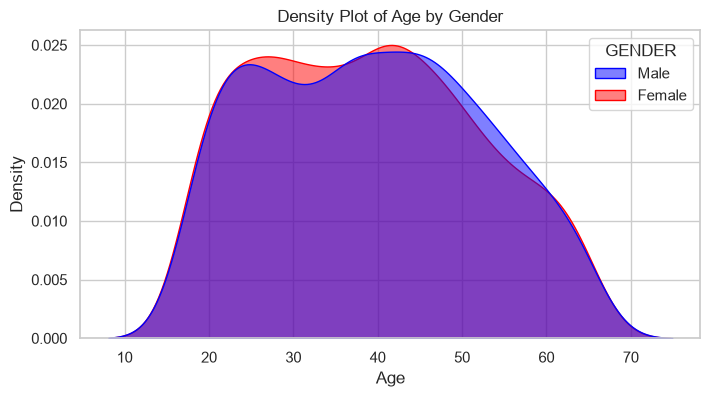

In [102]:

sns.set(style="whitegrid")

df_2['GENDER'] = df_1['GENDER'].map({0: 'Male', 1: 'Female'})

plt.figure(figsize=(8, 4))
sns.kdeplot(data=df_2, x='AGE', hue='GENDER', fill=True, common_norm=False, palette={"Male": "blue", "Female": "red"}, alpha=0.5)

# Add title and labels
plt.title('Density Plot of Age by Gender')
plt.xlabel('Age')
plt.ylabel('Density')

# Show the plot
plt.show()

**3rd Finding:** On a first glance we cannot observe any implicit dependecies and bias in the data wrt. our protected variables gender and race.

## 3. Classification of COUNTOP

We want to analyse the binary classification of the feature **COUNTOP**. To do this, the feature needs to be prepared.

## 3.1 Data Preparation

The feature **COUNTOP1** is added als a new variable for no outpatient visits (0) or at least 1 outpationet visit (1):

In [103]:
df_2 = df_1.copy()
df_2['COUNTOP1'] = np.where(df_2.COUNTOP == 0, 0, 1)
df_2 = df_2.drop(['COUNTIP', 'EXPENDIP', 'COUNTOP', 'EXPENDOP'], axis=1)

When splitting the data into training and testing sets, we use a 70/30 split.

In [104]:
# Training and testing sets
X = df_2.drop(['COUNTOP1'], axis=1)
Y = df_2.COUNTOP1
# train and test split
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.3,random_state=42)

In [105]:
# Target distribution in the training and testing Set
Target_Dist_Train = Y_train.value_counts(normalize=True).to_frame()
Target_Dist_Test  = Y_test.value_counts(normalize=True).to_frame()

print("Distribution COUNTOP1 training set: ")
print(Target_Dist_Train)
print("Distribution COUNTOP1 testing set: ")
print(Target_Dist_Test)

Distribution COUNTOP1 training set: 
          proportion
COUNTOP1            
1           0.668571
0           0.331429
Distribution COUNTOP1 testing set: 
          proportion
COUNTOP1            
1           0.693333
0           0.306667


In [107]:
# Target distribution in the training and testing set per GENDER
# Concatenate the train data with the predictions
df_train = pd.DataFrame(X_train)
df_train['COUNTOP1'] = Y_train
Target_Dist_Train_M = df_train[df_train['GENDER'] == 0]['COUNTOP1'].value_counts(normalize=True).to_frame()
Target_Dist_Train_F = df_train[df_train['GENDER'] == 1]['COUNTOP1'].value_counts(normalize=True).to_frame()

print("Distribution COUNTOP1 training set for Male: ")
print(Target_Dist_Train_M)
print("Distribution COUNTOP1 training set for Female: ")
print(Target_Dist_Train_F)

# Concatenate the test data with the predictions
df_test = pd.DataFrame(X_test)
df_test['COUNTOP1'] = Y_test
Target_Dist_Test_M = df_test[df_test['GENDER'] == 0]['COUNTOP1'].value_counts(normalize=True).to_frame()
Target_Dist_Test_F = df_test[df_test['GENDER'] == 1]['COUNTOP1'].value_counts(normalize=True).to_frame()

print("Distribution COUNTOP1 testing set for Male: ")
print(Target_Dist_Test_M)
print("Distribution COUNTOP1 testing set for Female: ")
print(Target_Dist_Test_F)

Distribution COUNTOP1 training set for Male: 
          proportion
COUNTOP1            
1            0.56305
0            0.43695
Distribution COUNTOP1 training set for Female: 
          proportion
COUNTOP1            
1           0.768802
0           0.231198
Distribution COUNTOP1 testing set for Male: 
          proportion
COUNTOP1            
1           0.583333
0           0.416667
Distribution COUNTOP1 testing set for Female: 
          proportion
COUNTOP1            
1           0.779762
0           0.220238


**Observation:** Females seem to have a higher prevalence for outpatient visits.

### 3.2 Modelling of COUNTOP1 with GENDER

To investigate the influence of **GENDER** on the bias, we continue by modelling the relationship between **COUNTOP1** and all the features incl. **GENDER**, serving as our initial analysis.

We will demonstrate in the workshoip only the modelling with XGBoost, Logistic Regression and Random Forest are demonstrated in the Appendix and show a similar behaviour.

As our initial model, we employ a classical XGBoost model with default settings. Following this, we report the performance metrics (accuracy, precision, and recall) as well as generate feature importance rankings.

In [108]:
# Modelling
model_xgb = xgb.XGBClassifier(random_state = 42)
model_xgb.fit(X_train, Y_train)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [109]:
# Prediction
Y_pred_xgb = model_xgb.predict(X_test)
Y_pred_prob_xgb = model_xgb.predict_proba(X_test)

In [110]:
# Target distribution in the training and testing set per GENDER
# Concatenate the test data with the predictions
df_test_xgb = pd.DataFrame(X_test)
df_test_xgb['COUNTOP1'] = Y_pred_xgb
Target_Dist_Test_M_xgb = df_test_xgb[df_test_xgb['GENDER'] == 0]['COUNTOP1'].value_counts(normalize=True).to_frame()
Target_Dist_Test_F_xgb = df_test_xgb[df_test_xgb['GENDER'] == 1]['COUNTOP1'].value_counts(normalize=True).to_frame()

print("Distribution COUNTOP1 testing set for Male: ")
print(Target_Dist_Test_M_xgb)
print("Distribution COUNTOP1 testing set for Female: ")
print(Target_Dist_Test_F_xgb)

Distribution COUNTOP1 testing set for Male: 
          proportion
COUNTOP1            
1           0.587121
0           0.412879
Distribution COUNTOP1 testing set for Female: 
          proportion
COUNTOP1            
1             0.8125
0             0.1875


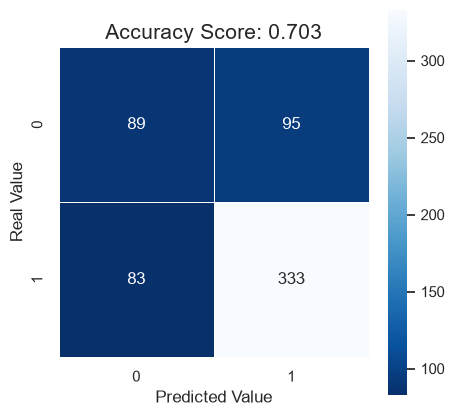

In [111]:
# Accuracy score
accuracy_xgb = accuracy_score(Y_test, Y_pred_xgb)
# Confusion Matrix 
cm = skmetrics.confusion_matrix(Y_test, Y_pred_xgb)
plt.figure(figsize=(5,5))
sns.heatmap(cm, annot=True, fmt=".0f", linewidths=.5, square = True, cmap = 'Blues_r');
plt.ylabel('Real Value');
plt.xlabel('Predicted Value');
all_sample_title = 'Accuracy Score: {0}'.format(round(accuracy_xgb,3))
plt.title(all_sample_title, size = 15);

In [112]:
# Metrics
print('Accuracy Score: {0}'.format(round(accuracy_xgb,3)))
precision_xgb = precision_score(Y_test, Y_pred_xgb)
print('Precision Score: {0}'.format(round(precision_xgb,3)))
recall_xgb = recall_score(Y_test, Y_pred_xgb)
print('Recall Score: {0}'.format(round(recall_xgb,3)))
auc_xgb = roc_auc_score(Y_test, Y_pred_prob_xgb[:,1])
print('Computed AUC: {0}'.format(round(auc_xgb,3)))
tpr_xgb = recall_xgb
tnr_xgb = recall_score(Y_test, Y_pred_xgb, pos_label=0)
fpr_xgb = 1 - tnr_xgb
fnr_xgb = 1 - tpr_xgb
print('False Positive Rate: {0}'.format(round(fpr_xgb,3)))
print('False Negative Rate: {0}'.format(round(fnr_xgb,3)))

Accuracy Score: 0.703
Precision Score: 0.778
Recall Score: 0.8
Computed AUC: 0.734
False Positive Rate: 0.516
False Negative Rate: 0.2


In [113]:
# Metrics by GENDER
df_test_xgb = pd.DataFrame(X_test)
df_test_xgb['COUNTOP1'] = Y_test
df_test_xgb['Y_pred_xgb'] = Y_pred_xgb

tpr_m_xgb = recall_score(df_test_xgb[df_test_xgb['GENDER']==0]['COUNTOP1'],\
                         df_test_xgb[df_test_xgb['GENDER']==0]['Y_pred_xgb'])
tnr_m_xgb = recall_score(df_test_xgb[df_test_xgb['GENDER']==0]['COUNTOP1'],\
                         df_test_xgb[df_test_xgb['GENDER']==0]['Y_pred_xgb'],pos_label=0)
fpr_m_xgb = 1 - tnr_m_xgb
fnr_m_xgb = 1 - tpr_m_xgb
print('False Positive Rate for Males: {0}'.format(round(fpr_m_xgb,3)))
print('False Negative Rate for Males: {0}'.format(round(fnr_m_xgb,3)))

tpr_f_xgb = recall_score(df_test_xgb[df_test_xgb['GENDER']==1]['COUNTOP1'],\
                         df_test_xgb[df_test_xgb['GENDER']==1]['Y_pred_xgb'])
tnr_f_xgb = recall_score(df_test_xgb[df_test_xgb['GENDER']==1]['COUNTOP1'],\
                         df_test_xgb[df_test_xgb['GENDER']==1]['Y_pred_xgb'],pos_label=0)
fpr_f_xgb = 1 - tnr_f_xgb
fnr_f_xgb = 1 - tpr_f_xgb
print('False Positive Rate for Females: {0}'.format(round(fpr_f_xgb,3)))
print('False Negative Rate for Females: {0}'.format(round(fnr_f_xgb,3)))

False Positive Rate for Males: 0.382
False Negative Rate for Males: 0.266
False Positive Rate for Females: 0.716
False Negative Rate for Females: 0.16


**Observation:** The false positive rate for females is very high and also much higher than teh FPR for males.

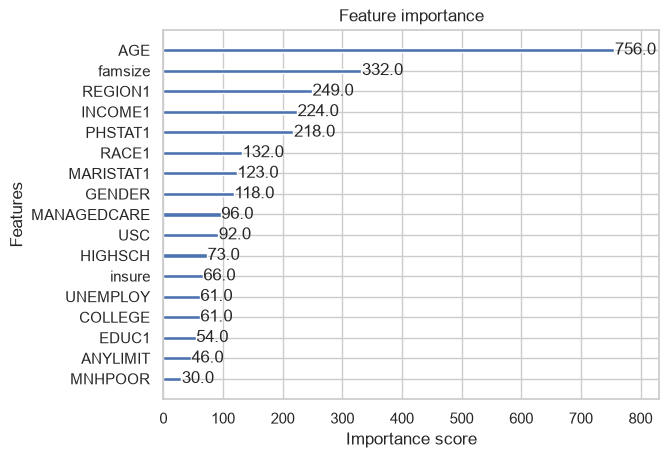

In [114]:
# Feature importance
plot_importance(model_xgb)
plt.show()

The feature **AGE** emerges as the most influential factor, followed by family size (**famsize*) and regional affiliation (**REGION1**). Notably, the model also incorporates the potentially sensitive features **GENDER** and **RACE1**.

### 3.3 Modelling of COUNTOP1 without GENDER

As our next step, we investigate the relationship between the target variable **COUNTOP1** and all features, excluding the sensitive characteristic **GENDER**.

In [115]:
# X_train_ng without GENDER
X_train_ng = X_train.drop(['GENDER'],axis=1)
X_test_ng = X_test.drop(['GENDER'],axis=1)

We will first demnonstrate the modelling with XGBoost. Please have a look in the Appensix for the other two models Logistig Regression and Rondom Forrest.

In [116]:
# Modelling
model_xgb_ng = xgb.XGBClassifier(random_state = 42)
model_xgb_ng.fit(X_train_ng, Y_train)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [117]:
# Prediction
Y_pred_xgb_ng = model_xgb_ng.predict(X_test_ng)
Y_pred_prob_xgb_ng = model_xgb_ng.predict_proba(X_test_ng)

In [118]:
# Target distribution in the training and testing set per GENDER
# Concatenate the test data with the predictions
df_test_xgb_ng = pd.DataFrame(X_test)
df_test_xgb_ng['COUNTOP1'] = Y_pred_xgb_ng
Target_Dist_Test_M_xgb_ng = df_test_xgb_ng[df_test_xgb_ng['GENDER'] == 0]['COUNTOP1'].value_counts(normalize=True).to_frame()
Target_Dist_Test_F_xgb_ng = df_test_xgb_ng[df_test_xgb_ng['GENDER'] == 1]['COUNTOP1'].value_counts(normalize=True).to_frame()

print("Distribution COUNTOP1 testing set for Male: ")
print(Target_Dist_Test_M_xgb_ng)
print("Distribution COUNTOP1 testing set for Female: ")
print(Target_Dist_Test_F_xgb_ng)

Distribution COUNTOP1 testing set for Male: 
          proportion
COUNTOP1            
1           0.681818
0           0.318182
Distribution COUNTOP1 testing set for Female: 
          proportion
COUNTOP1            
1           0.776786
0           0.223214


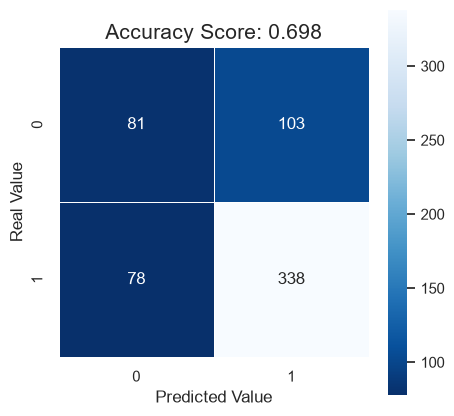

In [119]:
# Accuracy score
accuracy_xgb_ng = accuracy_score(Y_test, Y_pred_xgb_ng)
# Confusion Matrix 
cm = skmetrics.confusion_matrix(Y_test, Y_pred_xgb_ng)
plt.figure(figsize=(5,5))
sns.heatmap(cm, annot=True, fmt=".0f", linewidths=.5, square = True, cmap = 'Blues_r');
plt.ylabel('Real Value');
plt.xlabel('Predicted Value');
all_sample_title = 'Accuracy Score: {0}'.format(round(accuracy_xgb_ng,3))
plt.title(all_sample_title, size = 15);

In [120]:
# Metrics
print('Accuracy Score: {0}'.format(round(accuracy_xgb_ng,3)))
precision_xgb_ng = precision_score(Y_test, Y_pred_xgb_ng)
print('Precision Score: {0}'.format(round(precision_xgb_ng,3)))
recall_xgb_ng = recall_score(Y_test, Y_pred_xgb_ng)
print('Recall Score: {0}'.format(round(recall_xgb_ng,3)))
auc_xgb_ng = roc_auc_score(Y_test, Y_pred_prob_xgb_ng[:,1])
print('Computed AUC: {0}'.format(round(auc_xgb_ng,3)))
tpr_xgb_ng = recall_xgb_ng
tnr_xgb_ng = recall_score(Y_test, Y_pred_xgb_ng, pos_label=0)
fpr_xgb_ng = 1 - tnr_xgb_ng
fnr_xgb_ng = 1 - tpr_xgb_ng
print('False Positive Rate: {0}'.format(round(fpr_xgb_ng,3)))
print('False Negative Rate: {0}'.format(round(fnr_xgb_ng,3)))

Accuracy Score: 0.698
Precision Score: 0.766
Recall Score: 0.812
Computed AUC: 0.723
False Positive Rate: 0.56
False Negative Rate: 0.188


**Observation:** The Accuracy Score is only slightly smaller than for the model differentiating males and females.

In [121]:
# Metrics per GENDER
df_test_xgb_ng = pd.DataFrame(X_test)
df_test_xgb_ng['COUNTOP1'] = Y_test
df_test_xgb_ng['Y_pred_xgb_ng'] = Y_pred_xgb_ng

tpr_m_xgb_ng = recall_score(df_test_xgb_ng[df_test_xgb_ng['GENDER']==0]['COUNTOP1'],\
                            df_test_xgb_ng[df_test_xgb_ng['GENDER']==0]['Y_pred_xgb_ng'])
tnr_m_xgb_ng = recall_score(df_test_xgb_ng[df_test_xgb_ng['GENDER']==0]['COUNTOP1'],\
                            df_test_xgb_ng[df_test_xgb_ng['GENDER']==0]['Y_pred_xgb_ng'],pos_label=0)
fpr_m_xgb_ng = 1 - tnr_m_xgb_ng
fnr_m_xgb_ng = 1 - tpr_m_xgb_ng
print('False Positive Rate for Males: {0}'.format(round(fpr_m_xgb_ng,3)))
print('False Negative Rate for Males: {0}'.format(round(fnr_m_xgb_ng,3)))

tpr_f_xgb_ng = recall_score(df_test_xgb_ng[df_test_xgb_ng['GENDER']==1]['COUNTOP1'],\
                            df_test_xgb_ng[df_test_xgb_ng['GENDER']==1]['Y_pred_xgb_ng'])
tnr_f_xgb_ng = recall_score(df_test_xgb_ng[df_test_xgb_ng['GENDER']==1]['COUNTOP1'],\
                            df_test_xgb_ng[df_test_xgb_ng['GENDER']==1]['Y_pred_xgb_ng'],pos_label=0)
fpr_f_xgb_ng = 1 - tnr_f_xgb_ng
fnr_f_xgb_ng = 1 - tpr_f_xgb_ng
print('False Positive Rate for Females: {0}'.format(round(fpr_f_xgb_ng,3)))
print('False Negative Rate for Females: {0}'.format(round(fnr_f_xgb_ng,3)))

False Positive Rate for Males: 0.464
False Negative Rate for Males: 0.162
False Positive Rate for Females: 0.703
False Negative Rate for Females: 0.202


**Observation**: Still, the FPR for females is relevantly higher than the other rates.

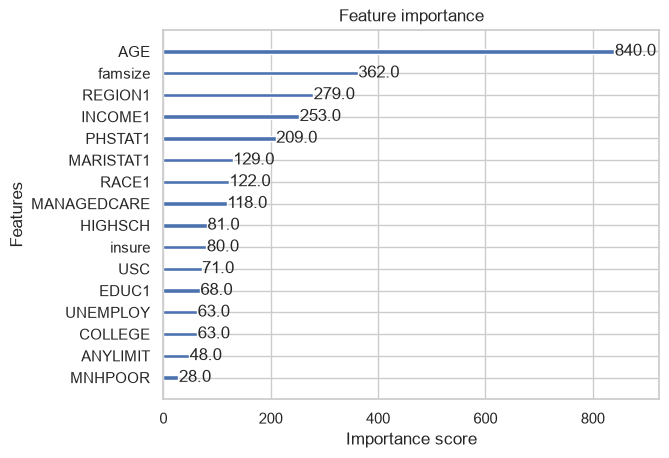

In [122]:
# Feature Importance
plot_importance(model_xgb_ng)
plt.show()

**Observation:** The feature importance ranking obtained without considering **GENDER** exhibits a comparable profile to that derived when including the sensitive characteristic, suggesting a degree of robustness in the results.

## 4 Preprocessing with Correlation Remover

An alternative strategy for feature modeling is discussed: the incorporation of a correlation removal technique enables the mitigation of spurious correlations to the sensitive variable, thereby diminishing the likelihood of proxy variable artefacts.

### 4.1 Correlation Remover

In [123]:
cr = CorrelationRemover(sensitive_feature_ids=['GENDER'], alpha=0.9)
cr.fit(X)

,sensitive_feature_ids,['GENDER']
,alpha,0.9
Name,Type,Value
beta_,"ndarray[float64](1, 16)","[[-0.4 , 0.01,-0.02,..., 0.18,-0.3 , 0.18]]"
lookup_,dict,"{'AGE': 0, 'AN...IT': 1, 'COLLEGE': 2, 'EDUC1': 13, ...}"
n_features_in_,int,17
sensitive_mean_,float64,0.527


In [125]:
# Transformation of X
X_cr_raw = cr.transform(X)

In [126]:
# Preparation of X_cr
X_cr = pd.DataFrame(
    X_cr_raw, columns=X.drop(['GENDER'],axis=1).columns
)
X_cr_g = X_cr.copy()
X_cr_g['GENDER'] = X['GENDER']
X_cr_g

,AGE,ANYLIMIT,COLLEGE,HIGHSCH,MNHPOOR,insure,USC,UNEMPLOY,MANAGEDCARE,famsize,RACE1,REGION1,EDUC1,MARISTAT1,INCOME1,PHSTAT1,GENDER
0,29.810331,0.003766,-0.01112,0.012004,0.010919,0.024274,0.066002,0.079220,0.018659,2.973379,3.968656,2.059149,-0.010235,1.085597,2.859353,0.085963,0
1,55.810331,1.003766,-0.01112,1.012004,0.010919,1.024274,1.066002,1.079220,1.018659,2.973379,1.968656,3.059149,0.989765,1.085597,2.859353,2.085963,0
2,54.810331,1.003766,0.98888,0.012004,0.010919,1.024274,1.066002,0.079220,0.018659,1.973379,3.968656,2.059149,1.989765,1.085597,3.859353,0.085963,0
3,47.170234,-0.003380,1.00998,-0.010774,-0.009800,0.978213,0.940761,-0.071103,-0.016747,2.023894,2.028132,0.946912,2.009186,0.923174,4.126236,2.922845,1
4,50.170234,-0.003380,1.00998,-0.010774,-0.009800,0.978213,0.940761,0.928897,0.983253,1.023894,4.028132,-0.053088,2.009186,2.923174,2.126236,1.922845,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,43.810331,1.003766,0.98888,0.012004,0.010919,0.024274,1.066002,0.079220,0.018659,0.973379,2.968656,0.059149,1.989765,0.085597,-0.140647,0.085963,0
1996,23.170234,-0.003380,0.00998,0.989226,-0.009800,-0.021787,-0.059239,-0.071103,-0.016747,7.023894,4.028132,-0.053088,1.009186,-0.076826,3.126236,1.922845,1
1997,33.810331,1.003766,-0.01112,0.012004,1.010919,0.024274,0.066002,0.079220,0.018659,0.973379,3.968656,2.059149,-0.010235,0.085597,0.859353,3.085963,0
1998,64.810331,1.003766,-0.01112,0.012004,0.010919,1.024274,1.066002,1.079220,0.018659,1.973379,3.968656,3.059149,-0.010235,1.085597,1.859353,3.085963,0


In [129]:
# Function to plot heatmap

def plot_heatmap(df, title):
    df_plot = df.copy()
    df_plot["target"] = Y
    cols = list(df_plot.columns)

    fig, ax = plt.subplots(figsize=(12, 12))
    ax.imshow(round(df_plot.corr(), 2), cmap="coolwarm")

    # Show all ticks and label them with the respective list entries
    ax.set_xticks(np.arange(len(cols)))
    ax.set_xticklabels(cols)
    ax.set_yticks(np.arange(len(cols)))
    ax.set_yticklabels(cols)

    # Rotate the tick labels and set their alignment.
    plt.setp(ax.get_xticklabels(), rotation=15, ha="right", rotation_mode="anchor")

    # Loop over data dimensions and create text annotations.
    for i in range(len(cols)):
        for j in range(len(cols)):
            ax.text(
                j,
                i,
                round(df_plot.corr().to_numpy()[i, j], 2),
                ha="center",
                va="center",
            )

    ax.set_title(f"{title}")
    plt.show()

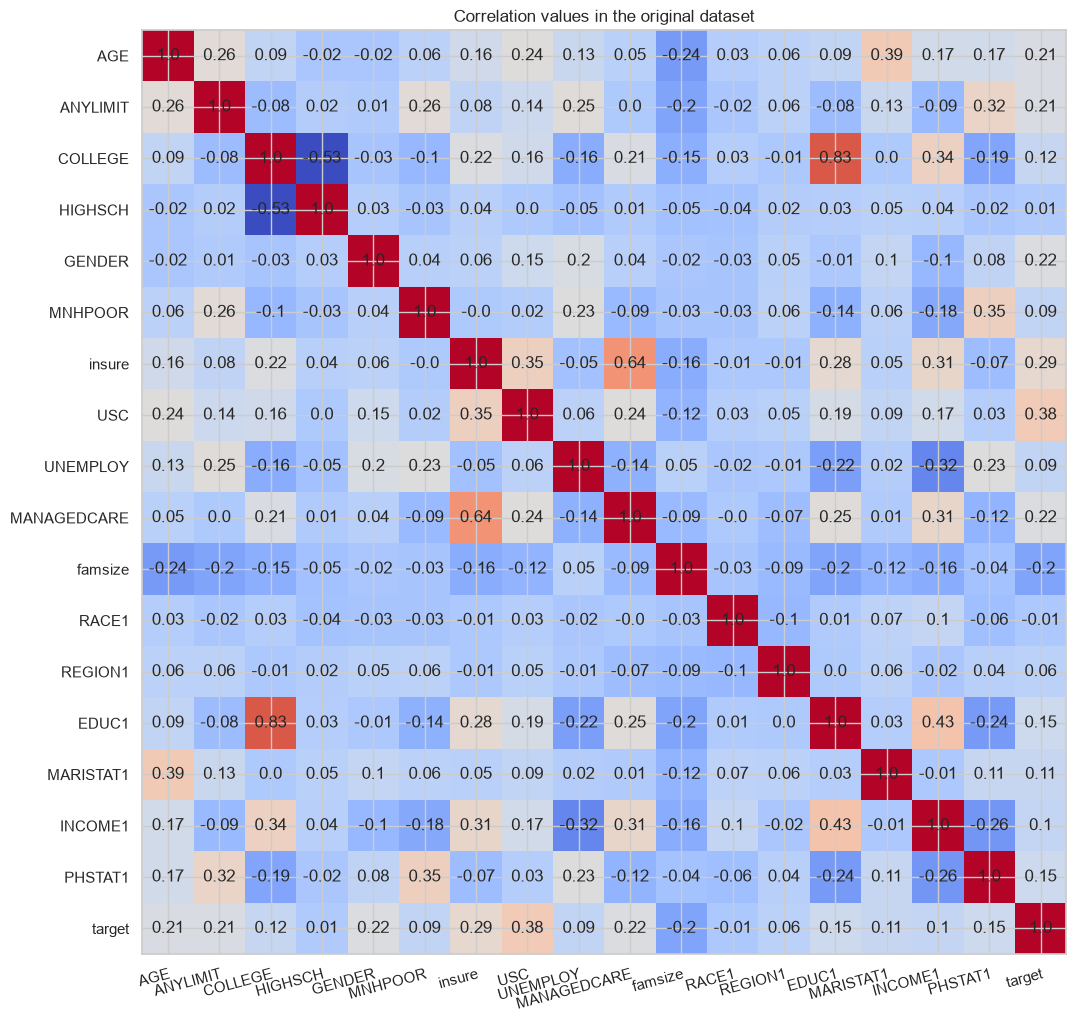

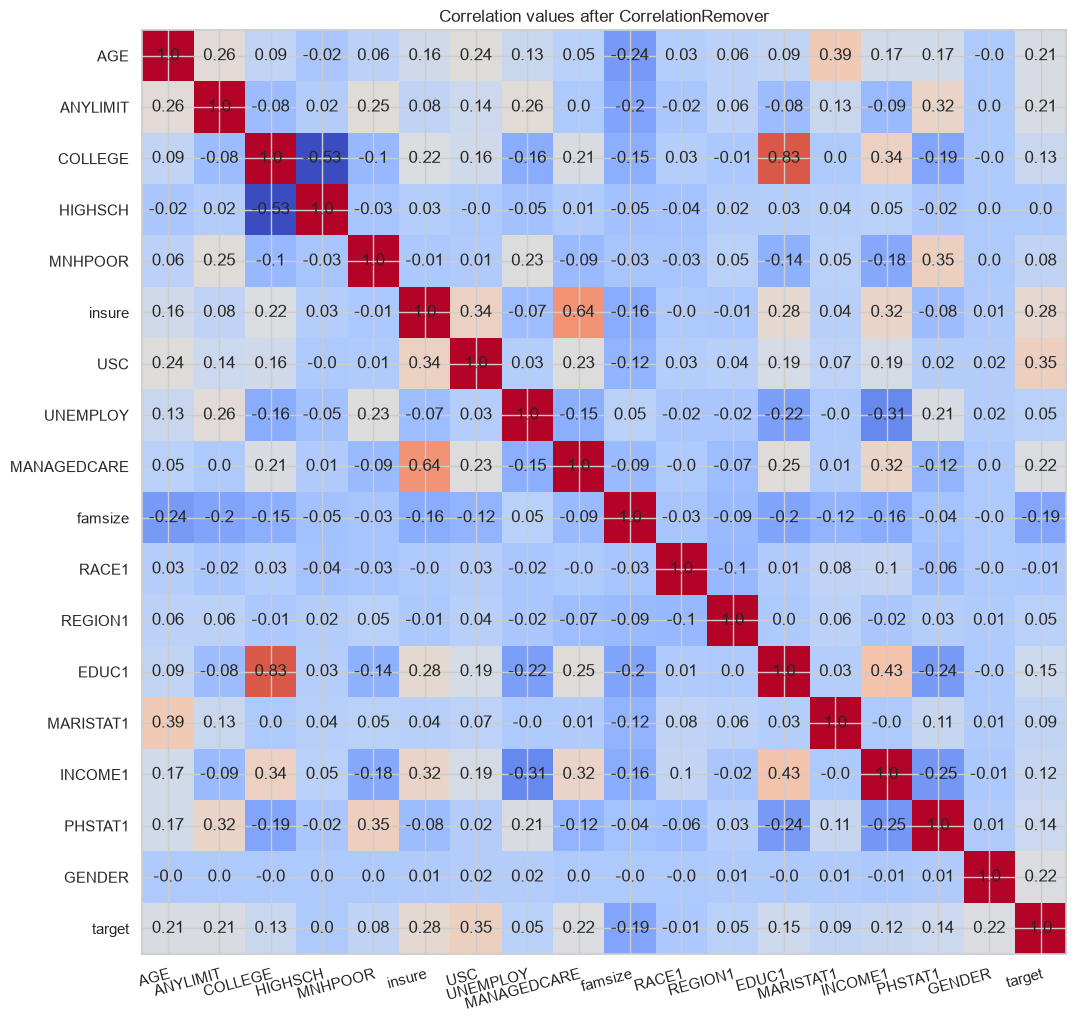

In [132]:
# Plot the correlation values of X and X_cr with correlation removed
plot_heatmap(X, "Correlation values in the original dataset")
plot_heatmap(X_cr_g, "Correlation values after CorrelationRemover")

**Observation:** A significant reduction in the correlation between the variables and the protected feature **GENDER** can be observed.

### 4.2 Modelling of the Modified Data Set

#### 4.2.1 Splitting the data into training and testing sets with Correlation Remover

In [135]:
# train and test split
X_train_cr,X_test_cr,Y_train_cr,Y_test_cr = train_test_split(X_cr,Y,test_size=0.3,random_state=42)

# Target Distribution in the Training and Testing Set
Target_Dist_Train_cr = Y_train_cr.value_counts(normalize=True).to_frame()
Target_Dist_Test_cr  = Y_test_cr.value_counts(normalize=True).to_frame()

print("Verteilung COUNTOP1 Traingsdatensatz: ")
print(Target_Dist_Train_cr)
print("Verteilung COUNTOP1 Testdatensatz: ")
print(Target_Dist_Test_cr)

Verteilung COUNTOP1 Traingsdatensatz: 
          proportion
COUNTOP1            
1           0.668571
0           0.331429
Verteilung COUNTOP1 Testdatensatz: 
          proportion
COUNTOP1            
1           0.693333
0           0.306667


#### 4.2.2 XGBoost with Correlation Remover

In [136]:
# Modelling
model_xgb_cr = xgb.XGBClassifier(random_state = 42)
model_xgb_cr.fit(X_train_cr, Y_train_cr)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [141]:
# Prediction
Y_pred_xgb_cr = model_xgb_cr.predict(X_test_cr)
Y_pred_prob_xgb_cr = model_xgb_cr.predict_proba(X_test_cr)

In [142]:
# Target Distribution in the Training and Testing Set per GENDER
# Concatenate the test data with the predictions
df_test_xgb_cr = pd.DataFrame(X_test)
df_test_xgb_cr['COUNTOP1'] = Y_pred_xgb_cr
Target_Dist_Test_M_xgb_cr = df_test_xgb_cr[df_test_xgb_cr['GENDER'] == 0]['COUNTOP1'].value_counts(normalize=True).to_frame()
Target_Dist_Test_F_xgb_cr = df_test_xgb_cr[df_test_xgb_cr['GENDER'] == 1]['COUNTOP1'].value_counts(normalize=True).to_frame()

print("Distribution COUNTOP1 testing set for Male: ")
print(Target_Dist_Test_M_xgb_cr)
print("Distribution COUNTOP1 testing set for Female: ")
print(Target_Dist_Test_F_xgb_cr)

Distribution COUNTOP1 testing set for Male: 
          proportion
COUNTOP1            
1           0.568182
0           0.431818
Distribution COUNTOP1 testing set for Female: 
          proportion
COUNTOP1            
1             0.8125
0             0.1875


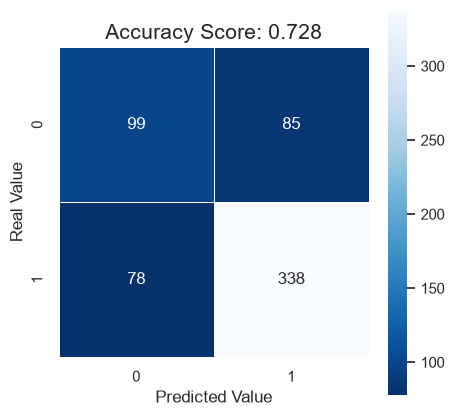

In [143]:
# Accuracy Score
accuracy_xgb_cr = accuracy_score(Y_test_cr, Y_pred_xgb_cr)
# Confusion Matrix 
cm = skmetrics.confusion_matrix(Y_test_cr, Y_pred_xgb_cr)
plt.figure(figsize=(5,5))
sns.heatmap(cm, annot=True, fmt=".0f", linewidths=.5, square = True, cmap = 'Blues_r');
plt.ylabel('Real Value');
plt.xlabel('Predicted Value');
all_sample_title = 'Accuracy Score: {0}'.format(round(accuracy_xgb_cr,3))
plt.title(all_sample_title, size = 15);

In [145]:
# Metrics
print('Accuracy Score: {0}'.format(round(accuracy_xgb_cr,3)))
precision_xgb_cr = precision_score(Y_test_cr, Y_pred_xgb_cr)
print('Precision Score: {0}'.format(round(precision_xgb_cr,3)))
recall_xgb_cr = recall_score(Y_test_cr, Y_pred_xgb_cr)
print('Recall Score: {0}'.format(round(recall_xgb_cr,3)))
auc_xgb_cr = roc_auc_score(Y_test_cr,Y_pred_prob_xgb_cr[:,1])
print('Computed AUC: {0}'.format(round(auc_xgb_cr,3)))
tpr_xgb_cr = recall_xgb_cr
tnr_xgb_cr = recall_score(Y_test_cr, Y_pred_xgb_cr, pos_label=0)
fpr_xgb_cr = 1 - tnr_xgb_cr
fnr_xgb_cr = 1 - tpr_xgb_cr
print('False Positive Rate: {0}'.format(round(fpr_xgb_cr,3)))
print('False Negative Rate: {0}'.format(round(fnr_xgb_cr,3)))

Accuracy Score: 0.728
Precision Score: 0.799
Recall Score: 0.812
Computed AUC: 0.741
False Positive Rate: 0.462
False Negative Rate: 0.188


In [146]:
# Metrics per GENDER
df_test_xgb_cr = pd.DataFrame(X_test)
df_test_xgb_cr['COUNTOP1'] = Y_test_cr
df_test_xgb_cr['Y_pred_xgb_cr'] = Y_pred_xgb_cr

tpr_m_xgb_cr = recall_score(df_test_xgb_cr[df_test_xgb_cr['GENDER']==0]['COUNTOP1'],\
                            df_test_xgb_cr[df_test_xgb_cr['GENDER']==0]['Y_pred_xgb_cr'])
tnr_m_xgb_cr = recall_score(df_test_xgb_cr[df_test_xgb_cr['GENDER']==0]['COUNTOP1'],\
                            df_test_xgb_cr[df_test_xgb_cr['GENDER']==0]['Y_pred_xgb_cr'],pos_label=0)
fpr_m_xgb_cr = 1 - tnr_m_xgb_cr
fnr_m_xgb_cr = 1 - tpr_m_xgb_cr
print('False Positive Rate for Males: {0}'.format(round(fpr_m_xgb_cr,3)))
print('False Negative Rate for Males: {0}'.format(round(fnr_m_xgb_cr,3)))

tpr_f_xgb_cr = recall_score(df_test_xgb_cr[df_test_xgb_cr['GENDER']==1]['COUNTOP1'],\
                            df_test_xgb_cr[df_test_xgb_cr['GENDER']==1]['Y_pred_xgb_cr'])
tnr_f_xgb_cr = recall_score(df_test_xgb_cr[df_test_xgb_cr['GENDER']==1]['COUNTOP1'],\
                            df_test_xgb_cr[df_test_xgb_cr['GENDER']==1]['Y_pred_xgb_cr'],pos_label=0)
fpr_f_xgb_cr = 1 - tnr_f_xgb_cr
fnr_f_xgb_cr = 1 - tpr_f_xgb_cr
print('False Positive Rate for Females: {0}'.format(round(fpr_f_xgb_cr,3)))
print('False Negative Rate for Females: {0}'.format(round(fnr_f_xgb_cr,3)))

False Positive Rate for Males: 0.327
False Negative Rate for Males: 0.26
False Positive Rate for Females: 0.662
False Negative Rate for Females: 0.145


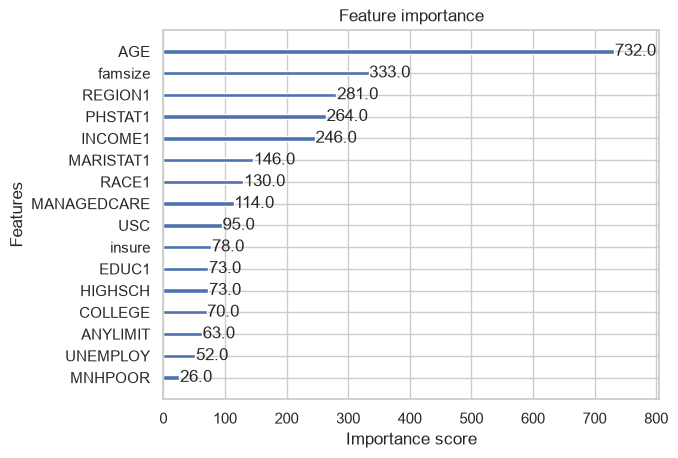

In [147]:
# Feature Importance
plot_importance(model_xgb_cr)
plt.show()

**Observation:** Our results indicate that the XGBoost model equipped with a correlation remover achieves a good performance on all metrics compared to its counterpart without the **GENDER** variable. 

## 5. Fairness Metrics

To further evaluate the performance of our constructed models, we propose applying various fairness metrics like Demographic Parity Difference and Equalized Odds to each model and comparing their results. This comparison will enable us to assess the relative merits of each model from the perspective of fairness.

### 5.1 Demographic Parity and Equalized Odds with GENDER

In [149]:
## Demographic Parity Difference of XGBoost Model with GENDER
dp_diff_xgb = demographic_parity_difference(y_true=Y_test, 
                                            y_pred=Y_pred_xgb,
                                            sensitive_features=X_test.GENDER)
print(f"Demographic Parity Difference of XGBoost Model with GENDER: {dp_diff_xgb}")

Demographic Parity Difference of XGBoost Model with GENDER: 0.22537878787878785


In [150]:
## Equalized Odds Difference of XGBoost Model with GENDER
eo_diff_xgb = equalized_odds_difference(y_true=Y_test, 
                                        y_pred=Y_pred_xgb,
                                        sensitive_features=X_test.GENDER)
print(f"Equalized Odds Difference of XGBoost Model with GENDER: {eo_diff_xgb}")

Equalized Odds Difference of XGBoost Model with GENDER: 0.3343980343980344


### 5.2 Demographic Parity and Equalized Odds without GENDER

In [151]:
## Demographic Parity Difference of XGBoost Model without GENDER
dp_diff_xgb_ng = demographic_parity_difference(y_true=Y_test, 
                                               y_pred=Y_pred_xgb_ng,
                                               sensitive_features=X_test.GENDER)
print(f"Demographic Parity Difference of XGBoost Model without GENDER: {dp_diff_xgb_ng}")

Demographic Parity Difference of XGBoost Model without GENDER: 0.09496753246753253


In [152]:
## Equalized Odds Difference of XGBoost Model without GENDER
eo_diff_xgb_ng = equalized_odds_difference(y_true=Y_test, 
                                           y_pred=Y_pred_xgb_ng,
                                           sensitive_features=X_test.GENDER)
print(f"Equalized Odds Difference of XGBoost Model without GENDER: {eo_diff_xgb_ng}")

Equalized Odds Difference of XGBoost Model without GENDER: 0.23906633906633912


### 5.3 Demographic Parity and Equalized Odds with Correlation Remover

In [154]:
## Demographic Parity Difference of XGBoost Model with Correlation Remover
dp_diff_xgb_cr = demographic_parity_difference(y_true=Y_test, 
                                               y_pred=Y_pred_xgb_cr,
                                               sensitive_features=X_test.GENDER)
print(f"Demographic Parity Difference of XGBoost Model with Correlation Remover: {dp_diff_xgb_cr}")

Demographic Parity Difference of XGBoost Model with Correlation Remover: 0.24431818181818177


In [155]:
## Equalized Odds Difference of XGBoost Model with Correlation Remover
eo_diff_xgb_cr = equalized_odds_difference(y_true=Y_test, 
                                           y_pred=Y_pred_xgb_cr,
                                           sensitive_features=X_test.GENDER)
print(f"Equalized Odds Difference of XGBoost Model with Correlation Remover: {eo_diff_xgb_cr}")

Equalized Odds Difference of XGBoost Model with Correlation Remover: 0.3348894348894349


### 5.4 Comparison of Fairness Metrics

In [158]:
# Fairness Metrics Table for all Models
df_Fairtable_sum = pd.DataFrame()
df_Fairtable_sum['Model'] = ['XGB w/ gender','XGB w/o gender','XGB Correlation Remover']
df_Fairtable_sum['Demographic Parity Difference'] = [dp_diff_xgb, dp_diff_xgb_ng, dp_diff_xgb_cr]
df_Fairtable_sum['Equalized Odds Difference'] = [eo_diff_xgb, eo_diff_xgb_ng, eo_diff_xgb_cr]
df_Fairtable_sum['Accuracy Score'] = [accuracy_xgb, accuracy_xgb_ng, accuracy_xgb_cr]  
df_Fairtable_sum.set_index("Model", inplace = True)
df_Fairtable_sum

,Demographic Parity Difference,Equalized Odds Difference,Accuracy Score
Model,,,
XGB w/ gender,0.225379,0.334398,0.703333
XGB w/o gender,0.094968,0.239066,0.698333
XGB Correlation Remover,0.244318,0.334889,0.728333


##### Observations:

- When removing the protected variable **GENDER**, we observe significant reductions in both Demographic Parity Difference and Equalized Odds Difference. These findings suggest that the removal of this variable has effectively mitigated gender bias within these models, resulting in improved fairness but also a lower Accuracy Score.

- The XGBoost model incorporating a Correlation Remover exhibits an increased Demographic Parity Difference and Equalized Odds Difference compared to the reference model, suggesting an increase in bias. However, also the Accuracy Score improved.

## 6. Conclusion

This notebook presents an analysis of three machine learning models (XGBoost, Logistic Regression, and Random Forest) applied to the Health Expenditures dataset for classification purposes. The investigation considered three scenarios: one involving the inclusion of GENDER as a protected variable, one without GENDER, and another with application of a correlation remover, with a view to exploring the effects of these different approaches on model performance and fairness characteristics.

Subsequent to model development, we conducted an comparative analysis of performance metrics (Accuracy, Precision, Recall, and AUC) and fairness metrics (Demographic Parity Difference and Equalized Odds Difference) across our models. Notably, while models that eliminated the protected variable GENDER were found to significantly reduce bias, this reduction came at the cost of decreased performance metric values. 

The Correlation Remover offers a preprocessing tool for addressing bias with respect to protected variables. Nevertheless, its application does not provide a guarantee of improved fairness metrics. In our Logistic Regression model, the correlation remover has been demonstrated to yield reduced fairness metrics compared to those without the protected variable; however, this improvement is less pronounced in other models. Notably, our XGBoost model exhibits only modest reductions in fairness metrics, whereas our Random Forest model experiences an increase in Demographic Parity Difference and Equalized Odds Difference relative to the reference model, thereby compounding bias.

Through the use of MetricFrame visualizations and comparative plots, practitioners can select models tailored to their specific goals. This notebook serves as a resource for providing examples and tools to facilitate exploration of additional metrics, methodologies and approaches.

---

## 7. Appendix

We now demonstrate the issues observed with XGBoost also for Logistx Regression and Rondom Forest models.

### 7.1 Models with Gender

#### 7.1.1 Logistic Regression with GENDER

Next, we fit a Logistic Regression model.

In [80]:
# Modelling
model_lr = LogisticRegression(random_state=42)
model_lr.fit(X_train, Y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solve

In [ ]:
# Prediction
Y_pred_lr = model_lr.predict(X_test)
Y_pred_prob_lr = model_lr.predict_proba(X_test)

In [ ]:
# Target distribution in the training and testing set per GENDER
# Concatenate the test data with the predictions
df_test_lr = pd.DataFrame(X_test)
df_test_lr['COUNTOP1'] = Y_pred_lr
Target_Dist_Test_M_lr = df_test_lr[df_test_lr['GENDER'] == 0]['COUNTOP1'].value_counts(normalize=True).to_frame()
Target_Dist_Test_F_lr = df_test_lr[df_test_lr['GENDER'] == 1]['COUNTOP1'].value_counts(normalize=True).to_frame()

print("Distribution COUNTOP1 testing set for Male: ")
print(Target_Dist_Test_M_lr)
print("Distribution COUNTOP1 testing set for Female: ")
print(Target_Dist_Test_F_lr)

Distribution COUNTOP1 testing set for Male: 
          proportion
COUNTOP1            
1           0.617424
0           0.382576
Distribution COUNTOP1 testing set for Female: 
          proportion
COUNTOP1            
1           0.886905
0           0.113095


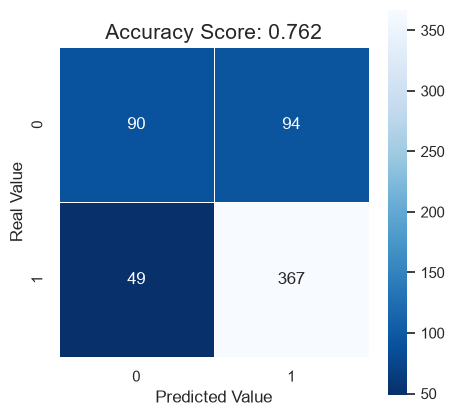

In [ ]:
# Accuracy Score
accuracy_lr = accuracy_score(Y_test, Y_pred_lr)
# Confusion Matrix 
cm = skmetrics.confusion_matrix(Y_test, Y_pred_lr)
plt.figure(figsize=(5,5))
sns.heatmap(cm, annot=True, fmt=".0f", linewidths=.5, square = True, cmap = 'Blues_r');
plt.ylabel('Real Value');
plt.xlabel('Predicted Value');
all_sample_title = 'Accuracy Score: {0}'.format(round(accuracy_lr,3))
plt.title(all_sample_title, size = 15);

In [ ]:
# Metrics
print('Accuracy Score: {0}'.format(round(accuracy_lr,3)))
precision_lr = precision_score(Y_test, Y_pred_lr)
print('Precision Score: {0}'.format(round(precision_lr,3)))
recall_lr = recall_score(Y_test, Y_pred_lr)
print('Recall Score: {0}'.format(round(recall_lr,3)))
auc_lr = roc_auc_score(Y_test,Y_pred_prob_lr[:,1])
print('Computed AUC: {0}'.format(round(auc_lr,3)))
tpr_lr = recall_lr
tnr_lr = recall_score(Y_test, Y_pred_lr, pos_label=0)
fpr_lr = 1 - tnr_lr
fnr_lr = 1 - tpr_lr
print('False Positive Rate: {0}'.format(round(fpr_lr,3)))
print('False Negative Rate: {0}'.format(round(fnr_lr,3)))

Accuracy Score: 0.762
Precision Score: 0.796
Recall Score: 0.882
Computed AUC: 0.797
False Positive Rate: 0.511
False Negative Rate: 0.118


In [ ]:
# Metrics per GENDER
df_test_lr = pd.DataFrame(X_test)
df_test_lr['COUNTOP1'] = Y_test
df_test_lr['Y_pred_lr'] = Y_pred_lr

tpr_m_lr = recall_score(df_test_lr[df_test_lr['GENDER']==0]['COUNTOP1'],\
                        df_test_lr[df_test_lr['GENDER']==0]['Y_pred_lr'])
tnr_m_lr = recall_score(df_test_lr[df_test_lr['GENDER']==0]['COUNTOP1'],\
                        df_test_lr[df_test_lr['GENDER']==0]['Y_pred_lr'],pos_label=0)
fpr_m_lr = 1 - tnr_m_lr
fnr_m_lr = 1 - tpr_m_lr
print('False Positive Rate for Males: {0}'.format(round(fpr_m_lr,3)))
print('False Negative Rate for Males: {0}'.format(round(fnr_m_lr,3)))

tpr_f_lr = recall_score(df_test_lr[df_test_lr['GENDER']==1]['COUNTOP1'],\
                        df_test_lr[df_test_lr['GENDER']==1]['Y_pred_lr'])
tnr_f_lr = recall_score(df_test_lr[df_test_lr['GENDER']==1]['COUNTOP1'],\
                        df_test_lr[df_test_lr['GENDER']==1]['Y_pred_lr'],pos_label=0)
fpr_f_lr = 1 - tnr_f_lr
fnr_f_lr = 1 - tpr_f_lr
print('False Positive Rate for Females: {0}'.format(round(fpr_f_lr,3)))
print('False Negative Rate for Females: {0}'.format(round(fnr_f_lr,3)))

False Positive Rate for Males: 0.345
False Negative Rate for Males: 0.188
False Positive Rate for Females: 0.757
False Negative Rate for Females: 0.076


**Observation:** Again the same issue for FPR for females.

In [ ]:
# Estimated Coefficients
coef_table = pd.DataFrame(list(X_train.columns)).copy()
coef_table.insert(len(coef_table.columns),"Coefs",model_lr.coef_.transpose())
print(coef_table)

              0     Coefs
0           AGE  0.010001
1      ANYLIMIT  0.887234
2       COLLEGE  0.086286
3       HIGHSCH -0.005068
4        GENDER  0.896025
5       MNHPOOR  0.156917
6        insure  0.439347
7           USC  1.157641
8      UNEMPLOY  0.177976
9   MANAGEDCARE  0.628771
10      famsize -0.136882
11        RACE1 -0.034031
12      REGION1  0.072613
13        EDUC1  0.167505
14    MARISTAT1  0.066045
15      INCOME1  0.040698
16      PHSTAT1  0.281151


#### 7.1.2 Random Forest with GENDER

Our third model fits a random forest classifier with default settings.

In [ ]:
# Modelling
model_rf = RandomForestClassifier(random_state = 42)
model_rf.fit(X_train, Y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [ ]:
# Prediction
Y_pred_rf = model_rf.predict(X_test)
Y_pred_prob_rf = model_rf.predict_proba(X_test)

In [ ]:
# Target Distribution in the Training and Testing Set per GENDER
# Concatenate the test data with the predictions
df_test_rf = pd.DataFrame(X_test)
df_test_rf['COUNTOP1'] = Y_pred_rf
Target_Dist_Test_M_rf = df_test_rf[df_test_rf['GENDER'] == 0]['COUNTOP1'].value_counts(normalize=True).to_frame()
Target_Dist_Test_F_rf = df_test_rf[df_test_rf['GENDER'] == 1]['COUNTOP1'].value_counts(normalize=True).to_frame()

print("Distribution COUNTOP1 testing set for Male: ")
print(Target_Dist_Test_M_rf)
print("Distribution COUNTOP1 testing set for Female: ")
print(Target_Dist_Test_F_rf)

Distribution COUNTOP1 testing set for Male: 
          proportion
COUNTOP1            
1              0.625
0              0.375
Distribution COUNTOP1 testing set for Female: 
          proportion
COUNTOP1            
1           0.892857
0           0.107143


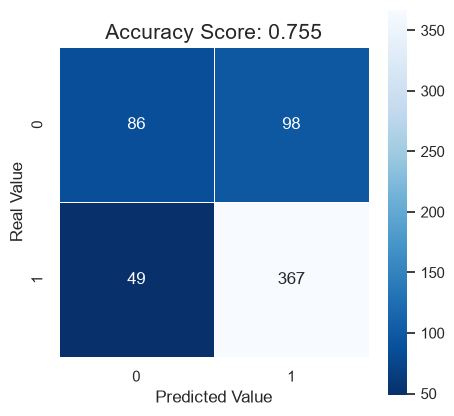

In [ ]:
# Accuracy score
accuracy_rf = accuracy_score(Y_test, Y_pred_rf)
# Confusion Matrix 
cm = skmetrics.confusion_matrix(Y_test, Y_pred_rf)
plt.figure(figsize=(5,5))
sns.heatmap(cm, annot=True, fmt=".0f", linewidths=.5, square = True, cmap = 'Blues_r');
plt.ylabel('Real Value');
plt.xlabel('Predicted Value');
all_sample_title = 'Accuracy Score: {0}'.format(round(accuracy_rf,3))
plt.title(all_sample_title, size = 15);

In [ ]:
# Metrics
print('Accuracy Score: {0}'.format(round(accuracy_rf,3)))
precision_rf = precision_score(Y_test, Y_pred_rf)
print('Precision Score: {0}'.format(round(precision_rf,3)))
recall_rf = recall_score(Y_test, Y_pred_rf)
print('Recall Score: {0}'.format(round(recall_rf,3)))
auc_rf = roc_auc_score(Y_test,Y_pred_prob_rf[:,1])
print('Computed AUC: {0}'.format(round(auc_rf,3)))
tpr_rf = recall_rf
tnr_rf = recall_score(Y_test, Y_pred_rf, pos_label=0)
fpr_rf = 1 - tnr_rf
fnr_rf = 1 - tpr_rf
print('False Positive Rate: {0}'.format(round(fpr_rf,3)))
print('False Negative Rate: {0}'.format(round(fnr_rf,3)))

Accuracy Score: 0.755
Precision Score: 0.789
Recall Score: 0.882
Computed AUC: 0.76
False Positive Rate: 0.533
False Negative Rate: 0.118


In [ ]:
# Metrics per GENDER
df_test_rf = pd.DataFrame(X_test)
df_test_rf['COUNTOP1'] = Y_test
df_test_rf['Y_pred_rf'] = Y_pred_rf

tpr_m_rf = recall_score(df_test_rf[df_test_rf['GENDER']==0]['COUNTOP1'],\
                        df_test_rf[df_test_rf['GENDER']==0]['Y_pred_rf'])
tnr_m_rf = recall_score(df_test_rf[df_test_rf['GENDER']==0]['COUNTOP1'],\
                        df_test_rf[df_test_rf['GENDER']==0]['Y_pred_rf'],pos_label=0)
fpr_m_rf = 1 - tnr_m_rf
fnr_m_rf = 1 - tpr_m_rf
print('False Positive Rate for Males: {0}'.format(round(fpr_m_rf,3)))
print('False Negative Rate for Males: {0}'.format(round(fnr_m_rf,3)))

tpr_f_rf = recall_score(df_test_rf[df_test_rf['GENDER']==1]['COUNTOP1'],\
                        df_test_rf[df_test_rf['GENDER']==1]['Y_pred_rf'])
tnr_f_rf = recall_score(df_test_rf[df_test_rf['GENDER']==1]['COUNTOP1'],\
                        df_test_rf[df_test_rf['GENDER']==1]['Y_pred_rf'],pos_label=0)
fpr_f_rf = 1 - tnr_f_rf
fnr_f_rf = 1 - tpr_f_rf
print('False Positive Rate for Females: {0}'.format(round(fpr_f_rf,3)))
print('False Negative Rate for Females: {0}'.format(round(fnr_f_rf,3)))

False Positive Rate for Males: 0.391
False Negative Rate for Males: 0.208
False Positive Rate for Females: 0.743
False Negative Rate for Females: 0.065


**Observation:** And again the same issue.

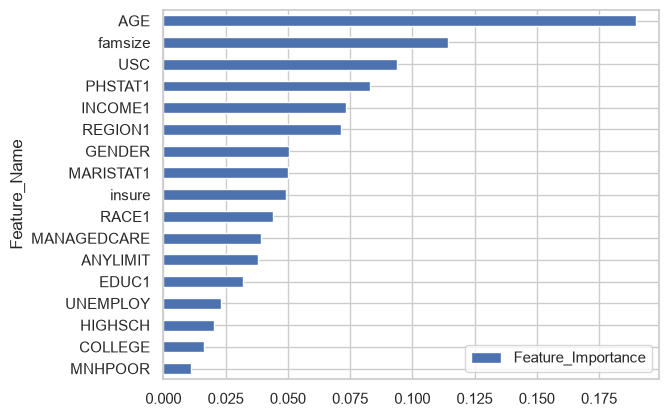

In [ ]:
# Feature Importance
Feature_Names_rf = pd.DataFrame(X_train.columns)
Feature_Names_rf.columns = ['Feature_Name']
Feature_Importance_rf = pd.DataFrame(model_rf.feature_importances_)
Feature_Importance_rf.columns = ['Feature_Importance']
RF_FI = Feature_Names_rf.merge(Feature_Importance_rf, left_index=True, right_index=True)
RF_FI.set_index("Feature_Name", inplace = True)
# Ramdom Forest: Feature-Importance plot
RF_FI.sort_values('Feature_Importance')
RF_FI.sort_values('Feature_Importance').plot(kind='barh')
plt.show()

Notably, **AGE** continues to emerge as the most influential feature, followed by family size (**famsize**) and the flag for persons being unsatified with the source of care (**USC**). Consistent with our previous findings using XGBoost, Random Forest also incorporates the features **GENDER** and **RACE1**. 

#### 7.1.3 Comparison of metrics for models with GENDER

A comparative analysis of the accuracy, precision, recall and AUC metrics for all models reveals that logistic regression surpasses machine learning methods employing default parameters in this particular instance.

In [ ]:
# Score Table with GENDER
df_Scoretable = pd.DataFrame()
df_Scoretable['Model'] = ['XGBoost', 'Logistic Regression', 'Random Forest']
df_Scoretable['Accuracy Score'] = [accuracy_xgb, accuracy_lr, accuracy_rf]
df_Scoretable['Precision Score'] = [precision_xgb, precision_lr, precision_rf]
df_Scoretable['Recall Score'] = [recall_xgb, recall_lr, recall_rf]
df_Scoretable['Computed AUC'] = [auc_xgb, auc_lr, auc_rf]
df_Scoretable['False Positive Rate'] = [fpr_xgb, fpr_lr, fpr_rf]
df_Scoretable['False Negative Rate'] = [fnr_xgb, fnr_lr, fnr_rf]
df_Scoretable.set_index("Model", inplace = True)
df_Scoretable

,Accuracy Score,Precision Score,Recall Score,Computed AUC,False Positive Rate,False Negative Rate
Model,,,,,,
XGBoost,0.726667,0.791667,0.822115,0.735917,0.489130,0.177885
Logistic Regression,0.763333,0.796537,0.884615,0.797881,0.510870,0.115385
Random Forest,0.755000,0.789247,0.882212,0.759628,0.532609,0.117788


### 7.2 Models without GENDER

We also fit Logistig Regression and Random Forest models without **GENDER**.

#### 7.2.1 Logistic Regression without GENDER

Next, we employ a Logistic Regression model without **GENDER**.

In [89]:
# Modelling
model_lr_ng = LogisticRegression(random_state=42)
model_lr_ng.fit(X_train_ng, Y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solve

In [90]:
# Prediction
Y_pred_lr_ng = model_lr_ng.predict(X_test_ng)
Y_pred_prob_lr_ng = model_lr_ng.predict_proba(X_test_ng)

In [91]:
# Target Distribution in the Training and Testing Set per GENDER
# Concatenate the test data with the predictions
df_test_lr_ng = pd.DataFrame(X_test)
df_test_lr_ng['COUNTOP1'] = Y_pred_lr_ng
Target_Dist_Test_M_lr_ng = df_test_lr_ng[df_test_lr_ng['GENDER'] == 0]['COUNTOP1'].value_counts(normalize=True).to_frame()
Target_Dist_Test_F_lr_ng = df_test_lr_ng[df_test_lr_ng['GENDER'] == 1]['COUNTOP1'].value_counts(normalize=True).to_frame()

print("Distribution COUNTOP1 testing set for Male: ")
print(Target_Dist_Test_M_lr_ng)
print("Distribution COUNTOP1 testing set for Female: ")
print(Target_Dist_Test_F_lr_ng)

Distribution COUNTOP1 testing set for Male: 
          proportion
COUNTOP1            
1           0.719697
0           0.280303
Distribution COUNTOP1 testing set for Female: 
          proportion
COUNTOP1            
1           0.830357
0           0.169643


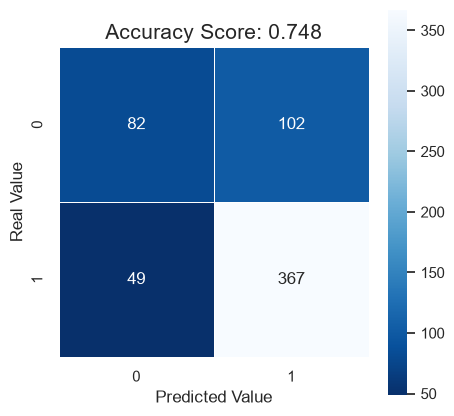

In [92]:
# Accuracy Score
accuracy_lr_ng = accuracy_score(Y_test, Y_pred_lr_ng)
# Confusion Matrix 
cm = skmetrics.confusion_matrix(Y_test, Y_pred_lr_ng)
plt.figure(figsize=(5,5))
sns.heatmap(cm, annot=True, fmt=".0f", linewidths=.5, square = True, cmap = 'Blues_r');
plt.ylabel('Real Value');
plt.xlabel('Predicted Value');
all_sample_title = 'Accuracy Score: {0}'.format(round(accuracy_lr_ng,3))
plt.title(all_sample_title, size = 15);

In [93]:
# Metrics
print('Accuracy Score: {0}'.format(round(accuracy_lr_ng,3)))
precision_lr_ng = precision_score(Y_test, Y_pred_lr_ng)
print('Precision Score: {0}'.format(round(precision_lr_ng,3)))
recall_lr_ng = recall_score(Y_test, Y_pred_lr_ng)
print('Recall Score: {0}'.format(round(recall_lr_ng,3)))
auc_lr_ng = roc_auc_score(Y_test, Y_pred_prob_lr_ng[:,1])
print('Computed AUC: {0}'.format(round(auc_lr_ng,3)))
tpr_lr_ng = recall_lr_ng
tnr_lr_ng = recall_score(Y_test, Y_pred_lr_ng, pos_label=0)
fpr_lr_ng = 1 - tnr_lr_ng
fnr_lr_ng = 1 - tpr_lr_ng
print('False Positive Rate: {0}'.format(round(fpr_lr_ng,3)))
print('False Negative Rate: {0}'.format(round(fnr_lr_ng,3)))

Accuracy Score: 0.748
Precision Score: 0.783
Recall Score: 0.882
Computed AUC: 0.791
False Positive Rate: 0.554
False Negative Rate: 0.118


In [94]:
# Metrics per GENDER
df_test_lr_ng = pd.DataFrame(X_test)
df_test_lr_ng['COUNTOP1'] = Y_test
df_test_lr_ng['Y_pred_lr_ng'] = Y_pred_lr_ng

tpr_m_lr_ng = recall_score(df_test_lr_ng[df_test_lr_ng['GENDER']==0]['COUNTOP1'],\
                           df_test_lr_ng[df_test_lr_ng['GENDER']==0]['Y_pred_lr_ng'])
tnr_m_lr_ng = recall_score(df_test_lr_ng[df_test_lr_ng['GENDER']==0]['COUNTOP1'],\
                           df_test_lr_ng[df_test_lr_ng['GENDER']==0]['Y_pred_lr_ng'],pos_label=0)
fpr_m_lr_ng = 1 - tnr_m_lr_ng
fnr_m_lr_ng = 1 - tpr_m_lr_ng
print('False Positive Rate for Males: {0}'.format(round(fpr_m_lr_ng,3)))
print('False Negative Rate for Males: {0}'.format(round(fnr_m_lr_ng,3)))

tpr_f_lr_ng = recall_score(df_test_lr_ng[df_test_lr_ng['GENDER']==1]['COUNTOP1'],\
                           df_test_lr_ng[df_test_lr_ng['GENDER']==1]['Y_pred_lr_ng'])
tnr_f_lr_ng = recall_score(df_test_lr_ng[df_test_lr_ng['GENDER']==1]['COUNTOP1'],\
                           df_test_lr_ng[df_test_lr_ng['GENDER']==1]['Y_pred_lr_ng'],pos_label=0)
fpr_f_lr_ng = 1 - tnr_f_lr_ng
fnr_f_lr_ng = 1 - tpr_f_lr_ng
print('False Positive Rate for Females: {0}'.format(round(fpr_f_lr_ng,3)))
print('False Negative Rate for Females: {0}'.format(round(fnr_f_lr_ng,3)))

False Positive Rate for Males: 0.482
False Negative Rate for Males: 0.11
False Positive Rate for Females: 0.662
False Negative Rate for Females: 0.122


In [95]:
# Estimated Coefficients
coef_table_ng = pd.DataFrame(list(X_train_ng.columns)).copy()
coef_table_ng.insert(len(coef_table_ng.columns),"Coefs",model_lr_ng.coef_.transpose())
print(coef_table_ng)

              0     Coefs
0           AGE  0.004230
1      ANYLIMIT  0.847225
2       COLLEGE  0.096755
3       HIGHSCH  0.021503
4       MNHPOOR  0.101731
5        insure  0.406174
6           USC  1.259193
7      UNEMPLOY  0.446437
8   MANAGEDCARE  0.629610
9       famsize -0.135778
10        RACE1 -0.049228
11      REGION1  0.093221
12        EDUC1  0.215014
13    MARISTAT1  0.133202
14      INCOME1  0.028994
15      PHSTAT1  0.314128


#### 7.2.2 Random Forest without GENDER

Our third model employs a random forest classifier with default settings without the sensitive variable GENDER.

In [96]:
# Modelling
model_rf_ng = RandomForestClassifier(random_state = 42)
model_rf_ng.fit(X_train_ng, Y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [97]:
# Prediction
Y_pred_rf_ng = model_rf_ng.predict(X_test_ng)
Y_pred_prob_rf_ng = model_rf_ng.predict_proba(X_test_ng)

In [98]:
# Target Distribution in the Training and Testing Set per GENDER
# Concatenate the test data with the predictions
df_test_rf_ng = pd.DataFrame(X_test)
df_test_rf_ng['COUNTOP1'] = Y_pred_rf_ng
Target_Dist_Test_M_rf_ng = df_test_rf_ng[df_test_rf_ng['GENDER'] == 0]['COUNTOP1'].value_counts(normalize=True).to_frame()
Target_Dist_Test_F_rf_ng = df_test_rf_ng[df_test_rf_ng['GENDER'] == 1]['COUNTOP1'].value_counts(normalize=True).to_frame()

print("Distribution COUNTOP1 testing set for Male: ")
print(Target_Dist_Test_M_rf_ng)
print("Distribution COUNTOP1 testing set for Female: ")
print(Target_Dist_Test_F_rf_ng)

Distribution COUNTOP1 testing set for Male: 
          proportion
COUNTOP1            
1           0.700758
0           0.299242
Distribution COUNTOP1 testing set for Female: 
          proportion
COUNTOP1            
1           0.791667
0           0.208333


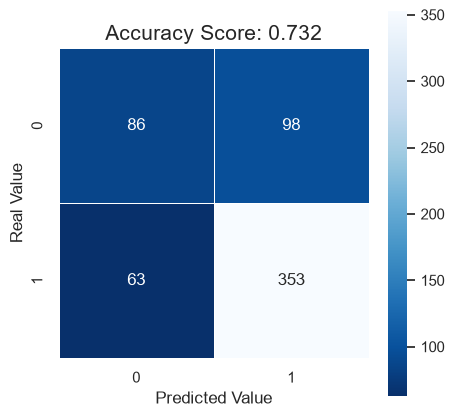

In [99]:
# Accuracy Score
accuracy_rf_ng = accuracy_score(Y_test, Y_pred_rf_ng)
# Confusion Matrix 
cm = skmetrics.confusion_matrix(Y_test, Y_pred_rf_ng)
plt.figure(figsize=(5,5))
sns.heatmap(cm, annot=True, fmt=".0f", linewidths=.5, square = True, cmap = 'Blues_r');
plt.ylabel('Real Value');
plt.xlabel('Predicted Value');
all_sample_title = 'Accuracy Score: {0}'.format(round(accuracy_rf_ng,3))
plt.title(all_sample_title, size = 15);

In [100]:
# Metrics
print('Accuracy Score: {0}'.format(round(accuracy_rf_ng,3)))
precision_rf_ng = precision_score(Y_test, Y_pred_rf_ng)
print('Precision Score: {0}'.format(round(precision_rf_ng,3)))
recall_rf_ng = recall_score(Y_test, Y_pred_rf_ng)
print('Recall Score: {0}'.format(round(recall_rf_ng,3)))
auc_rf_ng = roc_auc_score(Y_test, Y_pred_prob_rf_ng[:,1])
print('Computed AUC: {0}'.format(round(auc_rf_ng,3)))
tpr_rf_ng = recall_rf_ng
tnr_rf_ng = recall_score(Y_test, Y_pred_rf_ng, pos_label=0)
fpr_rf_ng = 1 - tnr_rf_ng
fnr_rf_ng = 1 - tpr_rf_ng
print('False Positive Rate: {0}'.format(round(fpr_rf_ng,3)))
print('False Negative Rate: {0}'.format(round(fnr_rf_ng,3)))

Accuracy Score: 0.732
Precision Score: 0.783
Recall Score: 0.849
Computed AUC: 0.756
False Positive Rate: 0.533
False Negative Rate: 0.151


In [102]:
# Metrics per GENDER
df_test_rf_ng = pd.DataFrame(X_test)
df_test_rf_ng['COUNTOP1'] = Y_test
df_test_rf_ng['Y_pred_rf_ng'] = Y_pred_rf_ng

tpr_m_rf_ng = recall_score(df_test_rf_ng[df_test_rf_ng['GENDER']==0]['COUNTOP1'],\
                           df_test_rf_ng[df_test_rf_ng['GENDER']==0]['Y_pred_rf_ng'])
tnr_m_rf_ng = recall_score(df_test_rf_ng[df_test_rf_ng['GENDER']==0]['COUNTOP1'],\
                           df_test_rf_ng[df_test_rf_ng['GENDER']==0]['Y_pred_rf_ng'],pos_label=0)
fpr_m_rf_ng = 1 - tnr_m_rf_ng
fnr_m_rf_ng = 1 - tpr_m_rf_ng
print('False Positive Rate for Males: {0}'.format(round(fpr_m_rf_ng,3)))
print('False Negative Rate for Males: {0}'.format(round(fnr_m_rf_ng,3)))

tpr_f_rf_ng = recall_score(df_test_rf_ng[df_test_rf_ng['GENDER']==1]['COUNTOP1'],\
                           df_test_rf_ng[df_test_rf_ng['GENDER']==1]['Y_pred_rf_ng'])
tnr_f_rf_ng = recall_score(df_test_rf_ng[df_test_rf_ng['GENDER']==1]['COUNTOP1'],\
                           df_test_rf_ng[df_test_rf_ng['GENDER']==1]['Y_pred_rf_ng'],pos_label=0)
fpr_f_rf_ng = 1 - tnr_f_rf_ng
fnr_f_rf_ng = 1 - tpr_f_rf_ng
print('False Positive Rate for Females: {0}'.format(round(fpr_f_rf_ng,3)))
print('False Negative Rate for Females: {0}'.format(round(fnr_f_rf_ng,3)))

False Positive Rate for Males: 0.482
False Negative Rate for Males: 0.143
False Positive Rate for Females: 0.608
False Negative Rate for Females: 0.156


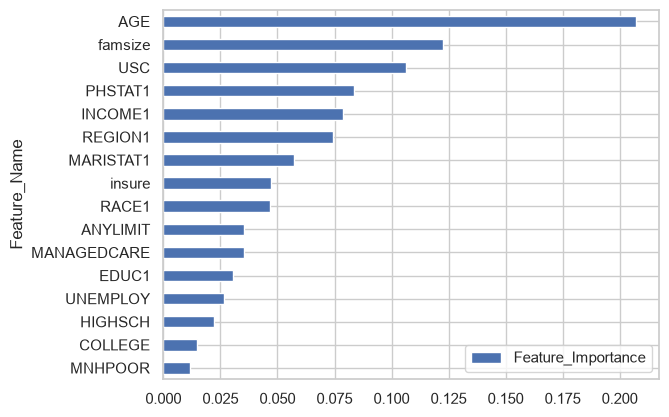

In [103]:
# Feature Importance
Feature_Names_rf_ng = pd.DataFrame(X_train_ng.columns)
Feature_Names_rf_ng.columns = ['Feature_Name']
Feature_Importance_rf_ng = pd.DataFrame(model_rf_ng.feature_importances_)
Feature_Importance_rf_ng.columns = ['Feature_Importance']
RF_FI_ng = Feature_Names_rf_ng.merge(Feature_Importance_rf_ng, left_index=True, right_index=True)
RF_FI_ng.set_index("Feature_Name", inplace = True)
# Ramdom Forest: Feature-Importance plotten
RF_FI_ng.sort_values('Feature_Importance')
RF_FI_ng.sort_values('Feature_Importance').plot(kind='barh')
plt.show()

### 7.3 Models with Correlation Remover

#### 7.3.1 Logistic Regression with Correlation Remover

In [ ]:
# Modelling
model_lr_cr = LogisticRegression(random_state=42)
model_lr_cr.fit(X_train_cr, y_train_cr)

LogisticRegression(random_state=42)

In [ ]:
# Prediction
y_pred_lr_cr = model_lr_cr.predict(X_test_cr)
y_pred_prob_lr_cr = model_lr_cr.predict_proba(X_test_cr)

In [ ]:
# Target Distribution in the Training and Testing Set per GENDER
# Concatenate the test data with the predictions
df_test_lr_cr = pd.DataFrame(X_test)
df_test_lr_cr['COUNTOP1'] = y_pred_lr_cr
Target_Dist_Test_M_lr_cr = df_test_lr_cr[df_test_lr_cr['GENDER'] == 0]['COUNTOP1'].value_counts(normalize=True).to_frame()
Target_Dist_Test_F_lr_cr = df_test_lr_cr[df_test_lr_cr['GENDER'] == 1]['COUNTOP1'].value_counts(normalize=True).to_frame()

print("Distribution COUNTOP1 testing set for Male: ")
print(Target_Dist_Test_M_lr_cr)
print("Distribution COUNTOP1 testing set for Female: ")
print(Target_Dist_Test_F_lr_cr)

Distribution COUNTOP1 testing set for Male: 
          proportion
COUNTOP1            
1               0.75
0               0.25
Distribution COUNTOP1 testing set for Female: 
          proportion
COUNTOP1            
1           0.809524
0           0.190476


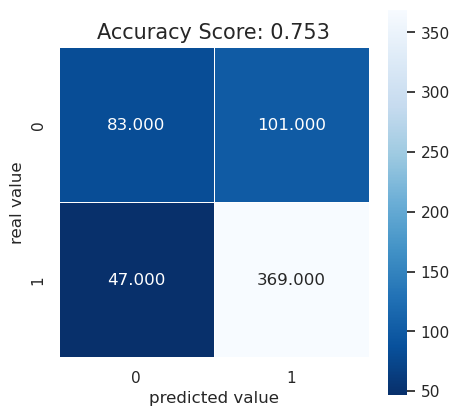

In [ ]:
# Accuracy Score
accuracy_lr_cr = accuracy_score(y_test_cr, y_pred_lr_cr)
# Confusion Matrix 
cm = skmetrics.confusion_matrix(y_test_cr, y_pred_lr_cr)
plt.figure(figsize=(5,5))
sns.heatmap(cm, annot=True, fmt=".3f", linewidths=.5, square = True, cmap = 'Blues_r');
plt.ylabel('real value');
plt.xlabel('predicted value');
all_sample_title = 'Accuracy Score: {0}'.format(round(accuracy_lr_cr,3))
plt.title(all_sample_title, size = 15);

In [ ]:
# Metrics
print('Accuracy Score: {0}'.format(round(accuracy_lr_cr,3)))
precision_lr_cr = precision_score(y_test_cr, y_pred_lr_cr)
print('Precision Score: {0}'.format(round(precision_lr_cr,3)))
recall_lr_cr = recall_score(y_test_cr, y_pred_lr_cr)
print('Recall Score: {0}'.format(round(recall_lr_cr,3)))
auc_lr_cr = roc_auc_score(y_test_cr,y_pred_prob_lr_cr[:,1])
print('Computed AUC: {0}'.format(round(auc_lr_cr,3)))
tpr_lr_cr = recall_lr_cr
tnr_lr_cr = recall_score(y_test, y_pred_lr_cr, pos_label=0)
fpr_lr_cr = 1 - tnr_lr_cr
fnr_lr_cr = 1 - tpr_lr_cr
print('False Positive Rate: {0}'.format(round(fpr_lr_cr,3)))
print('False Negative Rate: {0}'.format(round(fnr_lr_cr,3)))

Accuracy Score: 0.753
Precision Score: 0.785
Recall Score: 0.887
Computed AUC: 0.779
False Positive Rate: 0.549
False Negative Rate: 0.113


Also in this case the results indicate that the Logistic Regression model equipped with a correlation remover achieves superior performance on all metrics except AUC compared to its counterpart without the GENDER variable.

In [ ]:
# Metrics per GENDER
df_test_lr_cr = pd.DataFrame(X_test)
df_test_lr_cr['COUNTOP1'] = y_test_cr
df_test_lr_cr['y_pred_lr_cr'] = y_pred_lr_cr

tpr_m_lr_cr = recall_score(df_test_lr_cr[df_test_lr_cr['GENDER']==0]['COUNTOP1'],\
                           df_test_lr_cr[df_test_lr_cr['GENDER']==0]['y_pred_lr_cr'])
tnr_m_lr_cr = recall_score(df_test_lr_cr[df_test_lr_cr['GENDER']==0]['COUNTOP1'],\
                           df_test_lr_cr[df_test_lr_cr['GENDER']==0]['y_pred_lr_cr'],pos_label=0)
fpr_m_lr_cr = 1 - tnr_m_lr_cr
fnr_m_lr_cr = 1 - tpr_m_lr_cr
print('False Positive Rate for Males: {0}'.format(round(fpr_m_lr_cr,3)))
print('False Negative Rate for Males: {0}'.format(round(fnr_m_lr_cr,3)))

tpr_f_lr_cr = recall_score(df_test_lr_cr[df_test_lr_cr['GENDER']==1]['COUNTOP1'],\
                           df_test_lr_cr[df_test_lr_cr['GENDER']==1]['y_pred_lr_cr'])
tnr_f_lr_cr = recall_score(df_test_lr_cr[df_test_lr_cr['GENDER']==1]['COUNTOP1'],\
                           df_test_lr_cr[df_test_lr_cr['GENDER']==1]['y_pred_lr_cr'],pos_label=0)
fpr_f_lr_cr = 1 - tnr_f_lr_cr
fnr_f_lr_cr = 1 - tpr_f_lr_cr
print('False Positive Rate for Females: {0}'.format(round(fpr_f_lr_cr,3)))
print('False Negative Rate for Females: {0}'.format(round(fnr_f_lr_cr,3)))

False Positive Rate for Males: 0.518
False Negative Rate for Males: 0.084
False Positive Rate for Females: 0.595
False Negative Rate for Females: 0.13


In [ ]:
# Estimated Coefficients
coef_table_cr = pd.DataFrame(list(X_train_cr.columns)).copy()
coef_table_cr.insert(len(coef_table_cr.columns),"Coefs",model_lr_cr.coef_.transpose())
print(coef_table_cr)

              0     Coefs
0           AGE  0.008788
1      ANYLIMIT  0.831369
2       COLLEGE  0.090897
3       HIGHSCH -0.021714
4       MNHPOOR  0.079827
5        insure  0.384274
6           USC  1.177314
7      UNEMPLOY  0.248504
8   MANAGEDCARE  0.578991
9       famsize -0.116194
10        RACE1 -0.031073
11      REGION1  0.070958
12        EDUC1  0.160081
13    MARISTAT1  0.078967
14      INCOME1  0.050110
15      PHSTAT1  0.276825


#### 7.3.2 Random Forest with Correlation Remover

In [ ]:
# Modelling
model_rf_cr = RandomForestClassifier(random_state = 42)
model_rf_cr.fit(X_train_cr, y_train_cr)

RandomForestClassifier(random_state=42)

In [ ]:
# Prediction
y_pred_rf_cr = model_rf_cr.predict(X_test_cr)
y_pred_prob_rf_cr = model_rf_cr.predict_proba(X_test_cr)

In [ ]:
# Target Distribution in the Training and Testing Set per GENDER
# Concatenate the test data with the predictions
df_test_rf_cr = pd.DataFrame(X_test)
df_test_rf_cr['COUNTOP1'] = y_pred_rf_cr
Target_Dist_Test_M_rf_cr = df_test_rf_cr[df_test_rf_cr['GENDER'] == 0]['COUNTOP1'].value_counts(normalize=True).to_frame()
Target_Dist_Test_F_rf_cr = df_test_rf_cr[df_test_rf_cr['GENDER'] == 1]['COUNTOP1'].value_counts(normalize=True).to_frame()

print("Distribution COUNTOP1 testing set for Male: ")
print(Target_Dist_Test_M_rf_cr)
print("Distribution COUNTOP1 testing set for Female: ")
print(Target_Dist_Test_F_rf_cr)

Distribution COUNTOP1 testing set for Male: 
          proportion
COUNTOP1            
1           0.613636
0           0.386364
Distribution COUNTOP1 testing set for Female: 
          proportion
COUNTOP1            
1           0.895833
0           0.104167


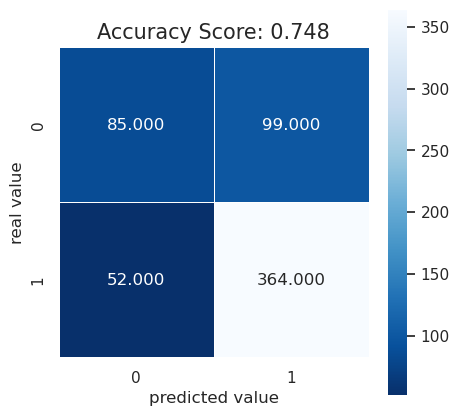

In [ ]:
# Accuracy Score
accuracy_rf_cr = accuracy_score(y_test_cr, y_pred_rf_cr)
# Confusion Matrix 
cm = skmetrics.confusion_matrix(y_test_cr, y_pred_rf_cr)
plt.figure(figsize=(5,5))
sns.heatmap(cm, annot=True, fmt=".3f", linewidths=.5, square = True, cmap = 'Blues_r');
plt.ylabel('real value');
plt.xlabel('predicted value');
all_sample_title = 'Accuracy Score: {0}'.format(round(accuracy_rf_cr,3))
plt.title(all_sample_title, size = 15);

In [ ]:
# Metrics
print('Accuracy Score: {0}'.format(round(accuracy_rf_cr,3)))
precision_rf_cr = precision_score(y_test_cr, y_pred_rf_cr)
print('Precision Score: {0}'.format(round(precision_rf,3)))
recall_rf_cr = recall_score(y_test_cr, y_pred_rf_cr)
print('Recall Score: {0}'.format(round(recall_rf_cr,3)))
auc_rf_cr = roc_auc_score(y_test_cr,y_pred_prob_rf_cr[:,1])
print('Computed AUC: {0}'.format(round(auc_rf_cr,3)))
tpr_rf_cr = recall_rf_cr
tnr_rf_cr = recall_score(y_test, y_pred_rf_cr, pos_label=0)
fpr_rf_cr = 1 - tnr_rf_cr
fnr_rf_cr = 1 - tpr_rf_cr
print('False Positive Rate: {0}'.format(round(fpr_rf_cr,3)))
print('False Negative Rate: {0}'.format(round(fnr_rf_cr,3)))

Accuracy Score: 0.748
Precision Score: 0.789
Recall Score: 0.875
Computed AUC: 0.754
False Positive Rate: 0.538
False Negative Rate: 0.125


In [ ]:
# Metrics per GENDER
df_test_rf_cr = pd.DataFrame(X_test)
df_test_rf_cr['COUNTOP1'] = y_test_cr
df_test_rf_cr['y_pred_rf_cr'] = y_pred_rf_cr

tpr_m_rf_cr = recall_score(df_test_rf_cr[df_test_rf_cr['GENDER']==0]['COUNTOP1'],\
                           df_test_rf_cr[df_test_rf_cr['GENDER']==0]['y_pred_rf_cr'])
tnr_m_rf_cr = recall_score(df_test_rf_cr[df_test_rf_cr['GENDER']==0]['COUNTOP1'],\
                           df_test_rf_cr[df_test_rf_cr['GENDER']==0]['y_pred_rf_cr'],pos_label=0)
fpr_m_rf_cr = 1 - tnr_m_rf_cr
fnr_m_rf_cr = 1 - tpr_m_rf_cr
print('False Positive Rate for Males: {0}'.format(round(fpr_m_rf_cr,3)))
print('False Negative Rate for Males: {0}'.format(round(fnr_m_rf_cr,3)))

tpr_f_rf_cr = recall_score(df_test_rf_cr[df_test_rf_cr['GENDER']==1]['COUNTOP1'],\
                           df_test_rf_cr[df_test_rf_cr['GENDER']==1]['y_pred_rf_cr'])
tnr_f_rf_cr = recall_score(df_test_rf_cr[df_test_rf_cr['GENDER']==1]['COUNTOP1'],\
                           df_test_rf_cr[df_test_rf_cr['GENDER']==1]['y_pred_rf_cr'],pos_label=0)
fpr_f_rf_cr = 1 - tnr_f_rf_cr
fnr_f_rf_cr = 1 - tpr_f_rf_cr
print('False Positive Rate for Females: {0}'.format(round(fpr_f_rf_cr,3)))
print('False Negative Rate for Females: {0}'.format(round(fnr_f_rf_cr,3)))

False Positive Rate for Males: 0.382
False Negative Rate for Males: 0.221
False Positive Rate for Females: 0.77
False Negative Rate for Females: 0.069


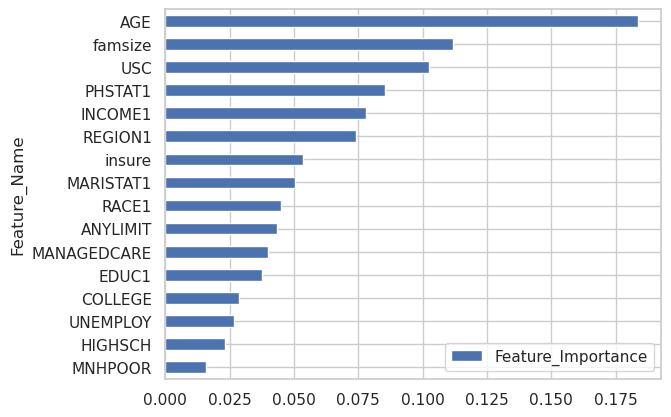

In [ ]:
# Feature Importance
Feature_Names_rf_cr = pd.DataFrame(X_train_cr.columns)
Feature_Names_rf_cr.columns = ['Feature_Name']
Feature_Importance_rf_cr = pd.DataFrame(model_rf_cr.feature_importances_)
Feature_Importance_rf_cr.columns = ['Feature_Importance']
RF_FI_cr = Feature_Names_rf_cr.merge(Feature_Importance_rf_cr, left_index=True, right_index=True)
RF_FI_cr.set_index("Feature_Name", inplace = True)
# Ramdom Forest: Feature-Importance plotten
RF_FI_cr.sort_values('Feature_Importance')
RF_FI_cr.sort_values('Feature_Importance').plot(kind='barh')
plt.show()

Also in this case the results indicate that the Random Forest model equipped with a correlation remover achieves superior performance on all metrics except AUC compared to its counterpart without the GENDER variable. Notably, the relative importance of the top-ranked features remained unchanged.

#### 7.3.3 Comparison of metrics for models with Correlation Remover

A comparative analysis of the accuracy, precision, recall and AUC metrics for all models reveals that logistic regression surpasses machine learning methods employing default parameters in this particular instance.

In [ ]:
# Score Table with Correlation Remover
df_Scoretable_cr = pd.DataFrame()
df_Scoretable_cr['Model'] = ['XGB_cr', 'LR_cr', 'RF_cr']
df_Scoretable_cr['Accuracy Score'] = [accuracy_xgb_cr, accuracy_lr_cr, accuracy_rf_cr]
df_Scoretable_cr['Precision Score'] = [precision_xgb_cr, precision_lr_cr, precision_rf_cr]
df_Scoretable_cr['Recall Score'] = [recall_xgb_cr, recall_lr_cr, recall_rf_cr]
df_Scoretable_cr['Computed AUC'] = [auc_xgb_cr, auc_lr_cr, auc_rf_cr]
df_Scoretable_cr['False Positive Rate'] = [fpr_xgb_cr, fpr_lr_cr, fpr_rf_cr]
df_Scoretable_cr['False Negative Rate'] = [fnr_xgb_cr, fnr_lr_cr, fnr_rf_cr]
df_Scoretable_cr.set_index("Model", inplace = True)
df_Scoretable_cr

,Accuracy Score,Precision Score,Recall Score,Computed AUC,False Positive Rate,False Negative Rate
Model,,,,,,
XGB_cr,0.708333,0.784870,0.798077,0.740254,0.494565,0.201923
LR_cr,0.753333,0.785106,0.887019,0.779212,0.548913,0.112981
RF_cr,0.748333,0.786177,0.875000,0.753926,0.538043,0.125000


### 7.4 Comparison of Metrics for all models

A comparative analysis of the accuracy, precision, recall and AUC metrics for all models reveals that logistic regression surpasses machine learning methods employing default parameters in this particular instance.

In [ ]:
# Score Table for all Models
df_Scoretable_sum = pd.DataFrame()
df_Scoretable_sum['Model'] = ['XGB','XGB_ng','XGB_cr', 'LR','LR_ng','LR_cr', 'RF', 'RF_ng', 'RF_cr']
df_Scoretable_sum['Accuracy Score'] = [accuracy_xgb, accuracy_xgb_ng, accuracy_xgb_cr, \
                                       accuracy_lr, accuracy_lr_ng, accuracy_lr_cr, \
                                       accuracy_rf, accuracy_rf_ng, accuracy_rf_cr]
df_Scoretable_sum['Precision Score'] = [precision_xgb, precision_xgb_ng, precision_xgb_cr, \
                                        precision_lr, precision_lr_ng, precision_lr_cr, \
                                        precision_rf, precision_rf_ng, precision_rf_cr]
df_Scoretable_sum['Recall Score'] = [recall_xgb, recall_xgb_ng, recall_xgb_cr, \
                                     recall_lr, recall_lr_ng, recall_lr_cr, \
                                     recall_rf, recall_rf_ng, recall_rf_cr]
df_Scoretable_sum['Computed AUC'] = [auc_xgb, auc_xgb_ng, auc_xgb_cr, \
                                     auc_lr, auc_lr_ng, auc_lr_cr, \
                                     auc_rf, auc_rf_ng, auc_rf_cr]
df_Scoretable_sum['False Positive Rate'] = [fpr_xgb, fpr_xgb_ng, fpr_xgb_cr, \
                                            fpr_lr, fpr_lr_ng, fpr_lr_cr, \
                                            fpr_rf, fpr_rf_ng, fpr_rf_cr]
df_Scoretable_sum['False Negative Rate'] = [fnr_xgb, fnr_xgb_ng, fnr_xgb_cr, \
                                            fnr_lr, fnr_lr_ng, fnr_lr_cr, \
                                            fnr_rf, fnr_rf_ng, fnr_rf_cr]
df_Scoretable_sum.set_index("Model", inplace = True)
df_Scoretable_sum

,Accuracy Score,Precision Score,Recall Score,Computed AUC,False Positive Rate,False Negative Rate
Model,,,,,,
XGB,0.726667,0.791667,0.822115,0.735917,0.489130,0.177885
XGB_ng,0.715000,0.782910,0.814904,0.726347,0.510870,0.185096
XGB_cr,0.708333,0.784870,0.798077,0.740254,0.494565,0.201923
LR,0.763333,0.796537,0.884615,0.797881,0.510870,0.115385
LR_ng,0.748333,0.782516,0.882212,0.790989,0.554348,0.117788
LR_cr,0.753333,0.785106,0.887019,0.779212,0.548913,0.112981
RF,0.755000,0.789247,0.882212,0.759628,0.532609,0.117788
RF_ng,0.731667,0.782705,0.848558,0.756062,0.532609,0.151442
RF_cr,0.748333,0.786177,0.875000,0.753926,0.538043,0.125000


- A comparative analysis reveals that XGBoost models with a correlation remover exhibit lightly inferior performance compared to their counterparts lacking the gender variable, and both inferior to the model incorporating gender information. 

- Conversely, Logistic Regression and Random Forest models equipped with a correlation remover demonstrate performance metrics comparable to those attained by models including gender information and lightly superior to the model lacking the gender variable.

In [ ]:
# False Rate per Gender for all Models
df_falserate_sum = pd.DataFrame()
df_falserate_sum['Model'] = ['XGB','XGB_ng','XGB_cr', 'LR','LR_ng','LR_cr', 'RF', 'RF_ng', 'RF_cr']
df_falserate_sum['False Positive Rate for Males'] = [fpr_m_xgb, fpr_m_xgb_ng, fpr_m_xgb_cr, \
                                                     fpr_m_lr, fpr_m_lr_ng, fpr_m_lr_cr, \
                                                     fpr_m_rf, fpr_m_rf_ng, fpr_m_rf_cr]
df_falserate_sum['False Negative Rate for Males'] = [fnr_m_xgb, fnr_m_xgb_ng, fnr_m_xgb_cr, \
                                                     fnr_m_lr, fnr_m_lr_ng, fnr_m_lr_cr, \
                                                     fnr_m_rf, fnr_m_rf_ng, fnr_m_rf_cr]
df_falserate_sum['False Positive Rate for Females'] = [fpr_f_xgb, fpr_f_xgb_ng, fpr_f_xgb_cr, \
                                                       fpr_f_lr, fpr_f_lr_ng, fpr_f_lr_cr, \
                                                       fpr_f_rf, fpr_f_rf_ng, fpr_f_rf_cr]
df_falserate_sum['False Negative Rate for Females'] = [fnr_f_xgb, fnr_f_xgb_ng, fnr_f_xgb_cr, \
                                                        fnr_f_lr, fnr_f_lr_ng, fnr_f_lr_cr, \
                                                        fnr_f_rf, fnr_f_rf_ng, fnr_f_rf_cr]
df_falserate_sum.set_index("Model", inplace = True)
df_falserate_sum

,False Positive Rate for Males,False Negative Rate for Males,False Positive Rate for Females,False Negative Rate for Females
Model,,,,
XGB,0.327273,0.246753,0.729730,0.137405
XGB_ng,0.445455,0.162338,0.608108,0.198473
XGB_cr,0.372727,0.279221,0.675676,0.156489
LR,0.336364,0.181818,0.770270,0.076336
LR_ng,0.481818,0.110390,0.662162,0.122137
LR_cr,0.518182,0.084416,0.594595,0.129771
RF,0.390909,0.207792,0.743243,0.064885
RF_ng,0.481818,0.142857,0.608108,0.156489
RF_cr,0.381818,0.220779,0.770270,0.068702


- In all models examined, females exhibited a significantly higher false positive rate compared to males. 
- Notably, the incorporation of gender as a variable into the ng-models substantially mitigated this disparity. 
- However, the Correlation Remover only achieved a reduction in disparity for XGBoost and Logistic Regression models, while actually increasing the gap in the Random Forest model. This finding underscores that the Correlation Remover does not guarantee a reduction in bias.

### 7.5 Fairness Metrics for other Models

#### 7.5.1 Logistic Regression with GENDER

In [ ]:
## Demographic Parity Difference of Logistic Regression Model with GENDER
dp_diff_lr = demographic_parity_difference(y_true=y_test, 
                                           y_pred=y_pred_lr,
                                           sensitive_features=X_test.GENDER)
print(f"Demographic Parity Difference of Logistic Regression with GENDER: {dp_diff_lr}")

Demographic Parity Difference of Logistic Regression with GENDER: 0.2724567099567099


In [ ]:
## Equalized Odds Difference of Logistic Regression Model with GENDER
eo_diff_lr = equalized_odds_difference(y_true=y_test, 
                                       y_pred=y_pred_lr,
                                       sensitive_features=X_test.GENDER)
print(f"Equalized odds Difference of Logistic Regression with GENDER: {eo_diff_lr}")

Equalized odds Difference of Logistic Regression with GENDER: 0.4339066339066339


#### 7.5.2 Random Forest with GENDER

In [ ]:
## Demographic Parity Difference of Random Forest Model with GENDER
dp_diff_rf = demographic_parity_difference(y_true=y_test, 
                                           y_pred=y_pred_rf,
                                           sensitive_features=X_test.GENDER)
print(f"Demographic Parity Difference of Random Forest with GENDER: {dp_diff_rf}")

Demographic Parity Difference of Random Forest with GENDER: 0.2678571428571429


In [ ]:
## Equalized Odds Difference of Random Forest Model with GENDER
eo_diff_rf = equalized_odds_difference(y_true=y_test, 
                                       y_pred=y_pred_rf,
                                       sensitive_features=X_test.GENDER)
print(f"Equalized Odds Difference of Random Forest with GENDER: {eo_diff_rf}")

Equalized Odds Difference of Random Forest with GENDER: 0.3523341523341523


#### 5.2.2 Logistic Regression without GENDER

In [ ]:
## Demographic Parity Difference of Logistic Regression Model without GENDER
dp_diff_lr_ng = demographic_parity_difference(y_true=y_test, 
                                              y_pred=y_pred_lr_ng,
                                              sensitive_features=X_test.GENDER)
print(f"Demographic Parity Difference of Logistic Regression without GENDER: {dp_diff_lr_ng}")

NameError: name 'y_test' is not defined

In [ ]:
## Equalized Odds Difference of Logistic Regression Model without GENDER
eo_diff_lr_ng = equalized_odds_difference(y_true=y_test, 
                                          y_pred=y_pred_lr_ng,
                                          sensitive_features=X_test.GENDER)
print(f"Equalized odds Difference of Logistic Regression without GENDER: {eo_diff_lr_ng}")

Equalized odds Difference of Logistic Regression without GENDER: 0.18034398034398036


#### 5.2.3 Random Forest without GENDER

In [ ]:
## Demographic Parity Difference of Random Forest Model without GENDER
dp_diff_rf_ng = demographic_parity_difference(y_true=y_test, 
                                              y_pred=y_pred_rf_ng,
                                              sensitive_features=X_test.GENDER)
print(f"Demographic Parity Difference of Random Forest without GENDER: {dp_diff_rf_ng}")

Demographic Parity Difference of Random Forest without GENDER: 0.09090909090909083


In [ ]:
## Equalized Odds Difference of Random Forest Model without GENDER
eo_diff_rf_ng = equalized_odds_difference(y_true=y_test, 
                                          y_pred=y_pred_rf_ng,
                                          sensitive_features=X_test.GENDER)
print(f"Equalized Odds Difference of Random Forest without GENDER: {eo_diff_rf_ng}")

Equalized Odds Difference of Random Forest without GENDER: 0.1262899262899263


#### 5.3.2 Logistic Regression mit Correlation Remover

In [ ]:
## Demographic Parity Difference of Logistic Regression with Correlation Remover
dp_diff_lr_cr = demographic_parity_difference(y_true=y_test, 
                                              y_pred=y_pred_lr_cr,
                                              sensitive_features=X_test.GENDER)
print(f"Demographic Parity Difference of Logistic Regression with Correlation Remover: {dp_diff_lr_cr}")

Demographic Parity Difference of Logistic Regression with Correlation Remover: 0.059523809523809534


In [ ]:
## Equalized Odds Difference of Logistic Regression with Correlation Remover
eo_diff_lr_cr = equalized_odds_difference(y_true=y_test, 
                                          y_pred=y_pred_lr_cr,
                                          sensitive_features=X_test.GENDER)
print(f"Equalized Odds Difference of Logistic Regression with Correlation Remover: {eo_diff_lr_cr}")

Equalized Odds Difference of Logistic Regression with Correlation Remover: 0.07641277641277644


#### 5.3.3 Random Forest with Correlation Remover

In [ ]:
## Demographic Parity Difference of Random Forest with Correlation Remover
dp_diff_rf_cr = demographic_parity_difference(y_true=y_test, 
                                              y_pred=y_pred_rf_cr,
                                              sensitive_features=X_test.GENDER)
print(f"Demographic Parity Difference of Random Forest with Correlation Remover: {dp_diff_rf_cr}")

Demographic Parity Difference of Random Forest with Correlation Remover: 0.2821969696969697


In [ ]:
## Equalized Odds Difference of Random Forest with Correlation Remover
eo_diff_rf_cr = equalized_odds_difference(y_true=y_test, 
                                          y_pred=y_pred_rf_cr,
                                          sensitive_features=X_test.GENDER)
print(f"Equalized Odds Difference of Random Forest with Correlation Remover: {eo_diff_rf_cr}")

Equalized Odds Difference of Random Forest with Correlation Remover: 0.38845208845208845


### 5.4 Comparison of Fairness Metrics for all models

In [ ]:
# Fairness Metrics Table for all Models
df_Fairtable_sum = pd.DataFrame()
df_Fairtable_sum['Model'] = ['XGB','XGB_ng','XGB_cr', 'LR','LR_ng','LR_cr', 'RF', 'RF_ng', 'RF_cr']
df_Fairtable_sum['Demographic Parity Difference'] = [dp_diff_xgb, dp_diff_xgb_ng, dp_diff_xgb_cr, \
                                                     dp_diff_lr, dp_diff_lr_ng, dp_diff_lr_cr, \
                                                     dp_diff_rf, dp_diff_rf_ng, dp_diff_rf_cr]
df_Fairtable_sum['Equalized Odds Difference'] = [eo_diff_xgb, eo_diff_xgb_ng, eo_diff_xgb_cr, \
                                                 eo_diff_lr, eo_diff_lr_ng, eo_diff_lr_cr, \
                                                 eo_diff_rf, eo_diff_rf_ng, eo_diff_rf_cr]
df_Fairtable_sum.set_index("Model", inplace = True)
df_Fairtable_sum

,Demographic Parity Difference,Equalized Odds Difference
Model,,
XGB,0.257576,0.402457
XGB_ng,0.084686,0.162654
XGB_cr,0.230790,0.302948
LR,0.272457,0.433907
LR_ng,0.110660,0.180344
LR_cr,0.059524,0.076413
RF,0.267857,0.352334
RF_ng,0.090909,0.126290
RF_cr,0.282197,0.388452


##### Observations:

- Upon removing the protected variable GENDER, we observe significant reductions in both Demographic Parity Difference and Equalized Odds Difference. These findings suggest that the removal of this variable has effectively mitigated gender bias within these models, resulting in improved fairness.

- The XGBoost model incorporating a Correlation Remover exhibits reduced Demographic Parity Difference and Equalized Odds Difference compared to the reference model, suggesting a reduction in bias. However, the values are much higer than that of the model without the protected variable GENDER and the gain in fairness is accompanied by a corresponding decrease in all performance metrics except the AUC.

- The Logistic Regression model with Correlation Remover demonstrates a more pronounced reduction in Demographic Parity Difference and Equalized Odds Difference compared to the model without the protected variable GENDER. This gain in fairness metrics is particularly noteworthy, as it occurs without compromising the model's performance relative to the reference model.

- Contrary to our expectations, the Random Forest model with Correlation Remover exhibits an increase in Demographic Parity Difference and Equalized Odds Difference relative to the reference model. This outcome suggests that the incorporation of a Correlation Remover has not contributed to a reduction in bias.